In [1]:
import os, string, shapely, itertools

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import shapely.ops as so

from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.transforms import ScaledTranslation
from shapely.ops import cascaded_union
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D
from shapely.validation import make_valid

import scipy.interpolate as inter

plt.rcParams['legend.handlelength'] = 1
plt.rcParams['legend.handleheight'] = 1.125
plt.rcParams["font.family"]         = "Avenir"

path_to_images = '/Users/Guille/Desktop/india_power/images'
path_to_csvs   = '/Users/Guille/Desktop/india_power/gridpath_india_viz/csvs'
path_to_input  = '/Users/Guille/Desktop/india_power/input_data/'
path_to_load   = '/Users/Guille/Desktop/india_power/input_data/load'
path_to_data   = '/Users/Guille/Desktop/india_power/gridpath_india_viz/data'
path_to_tables = '/Users/Guille/Desktop/india_power/tables'

# Technology Cost Projections

In [2]:
# New projects costs and operational characteristics
new_projects_excel            = path_to_input + "new_projects_v41.xlsx"
new_battery_costs_all         = pd.read_excel(new_projects_excel, sheet_name = "adapted_new_battery_costs_2050")
new_hydrogen_cavern_costs_all = pd.read_excel(new_projects_excel, sheet_name = "new_hydrogen_cavern_costs_2050")
new_hydrogen_tank_costs_all   = pd.read_excel(new_projects_excel, sheet_name = "new_hydrogen_tank_costs_2050")
new_solar_costs_all           = pd.read_excel(new_projects_excel, sheet_name = "adapted_new_solar_costs_2050")
new_wind_costs_all            = pd.read_excel(new_projects_excel, sheet_name = "adapted_new_wind_costs_2050")
new_conventional_costs_all    = pd.read_excel(new_projects_excel, sheet_name = "new_conventional_costs_2050")
new_nuclear_costs_all         = pd.read_excel(new_projects_excel, sheet_name = "new_nuclear_costs_2050")
new_hydro_costs_all           = pd.read_excel(new_projects_excel, sheet_name = "new_hydro_pumped_costs_2050")

# Exchange Rate
USD_to_INR = 72

2024    391658.821606
2025    378354.602279
2026    365502.312648
2027    353086.601157
2028    341092.637728
2029    329506.096042
2030    318313.136432
2031    306672.719436
2032    295457.981722
2033    284653.356595
2034    274243.846615
2035    264215.002788
2036    254552.904504
2037    245244.140218
2038    236275.788833
2039    227635.401763
2040    219310.985656
2041    215832.294759
Name: EG_SOLARGM, dtype: float64


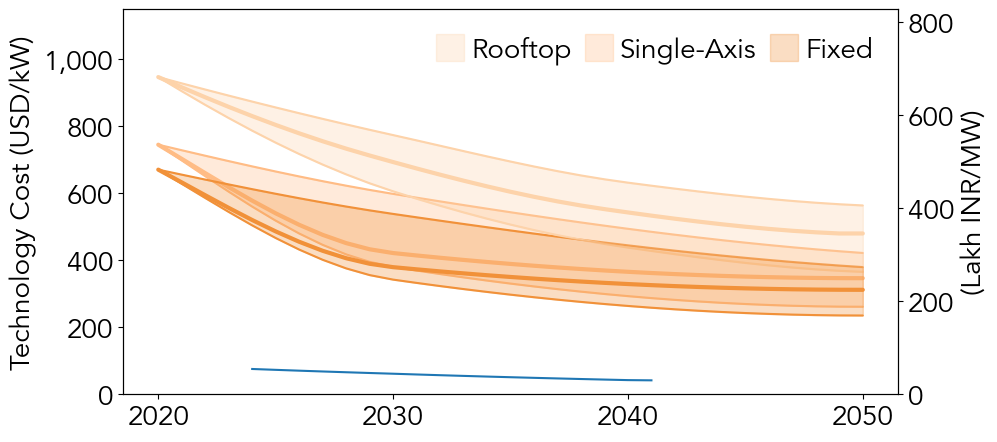

In [61]:
def _plot_solar_cost(ax, df_, 
                     ylabel  = r'Technology Cost (USD/kW)',
                     yplabel = r'(Lakh INR/MW)',
                     xlabel  = True):

    idx_single_low_  = (df_['scenario'] == 'PVlow') & (df_['technology'] == 'SolarPV_single')
    idx_single_mid_  = (df_['scenario'] == 'PVmid') & (df_['technology'] == 'SolarPV_single')
    idx_single_high_ = (df_['scenario'] == 'PVhigh') & (df_['technology'] == 'SolarPV_single')

    idx_tilt_low_  = (df_['scenario'] == 'PVlow') & (df_['technology'] == 'SolarPV_tilt')
    idx_tilt_mid_  = (df_['scenario'] == 'PVmid') & (df_['technology'] == 'SolarPV_tilt')
    idx_tilt_high_ = (df_['scenario'] == 'PVhigh') & (df_['technology'] == 'SolarPV_tilt')

    idx_roof_low_  = (df_['scenario'] == 'PVlow') & (df_['technology'] == 'SolarPV_roof')
    idx_roof_mid_  = (df_['scenario'] == 'PVmid') & (df_['technology'] == 'SolarPV_roof')
    idx_roof_high_ = (df_['scenario'] == 'PVhigh') & (df_['technology'] == 'SolarPV_roof')
    
    ax.plot(df_.loc[idx_roof_low_, 'vintage'], df_.loc[idx_roof_low_, 'capital_real_cost_per_kw'],
            color = '#fdd3aa', lw = 1.5, zorder = 2, solid_capstyle='round')
    ax.plot(df_.loc[idx_roof_mid_, 'vintage'], df_.loc[idx_roof_mid_, 'capital_real_cost_per_kw'],
            color = '#fdd3aa', lw = 3, zorder = 2, solid_capstyle='round')
    ax.plot(df_.loc[idx_roof_high_, 'vintage'], df_.loc[idx_roof_high_, 'capital_real_cost_per_kw'],
            color = '#fdd3aa', lw = 1.5, zorder = 2, solid_capstyle='round')
    
    ax.fill_between(df_.loc[idx_roof_mid_, 'vintage'], 
                    df_.loc[idx_roof_low_, 'capital_real_cost_per_kw'],
                    df_.loc[idx_roof_high_, 'capital_real_cost_per_kw'], 
                    color = '#fdd3aa', alpha = .3, label = 'Rooftop', zorder = 2)
    
    ax.plot(df_.loc[idx_single_low_, 'vintage'], df_.loc[idx_single_low_, 'capital_real_cost_per_kw'],
            color = '#ffbc85', lw = 1.5, zorder = 1, solid_capstyle='round')
    ax.plot(df_.loc[idx_single_mid_, 'vintage'], df_.loc[idx_single_mid_, 'capital_real_cost_per_kw'],
            color = '#ffbc85', lw = 3, zorder = 1, solid_capstyle='round')
    ax.plot(df_.loc[idx_single_high_, 'vintage'], df_.loc[idx_single_high_, 'capital_real_cost_per_kw'],
            color = '#ffbc85', lw = 1.5, zorder = 1, solid_capstyle='round')

    ax.fill_between(df_.loc[idx_single_mid_, 'vintage'], 
                    df_.loc[idx_single_low_, 'capital_real_cost_per_kw'],
                    df_.loc[idx_single_high_, 'capital_real_cost_per_kw'], 
                    color = '#ffbc85', alpha = .3, label = 'Single-Axis', zorder = 1)

    ax.plot(df_.loc[idx_tilt_low_, 'vintage'], df_.loc[idx_tilt_low_, 'capital_real_cost_per_kw'],
            color = '#f19139', lw = 1.5, zorder = 1.5, solid_capstyle='round')
    ax.plot(df_.loc[idx_tilt_mid_, 'vintage'], df_.loc[idx_tilt_mid_, 'capital_real_cost_per_kw'],
            color = '#f19139', lw = 3, zorder = 3, solid_capstyle='round')
    ax.plot(df_.loc[idx_tilt_high_, 'vintage'], df_.loc[idx_tilt_high_, 'capital_real_cost_per_kw'],
            color = '#f19139', lw = 1.5, zorder = 1.5, solid_capstyle='round')

    ax.fill_between(df_.loc[idx_tilt_mid_, 'vintage'], 
                    df_.loc[idx_tilt_low_, 'capital_real_cost_per_kw'],
                    df_.loc[idx_tilt_high_, 'capital_real_cost_per_kw'], 
                    color = '#f19139', alpha = .3, label = 'Fixed', zorder = 3)
    
    ax.legend(loc     = 'upper right',
              ncol    = 3,
              frameon = False,
              prop    = {'size': 20},
              handletextpad = 0.25,
              columnspacing = 0.5)

    x_ = np.array([2020, 2030, 2040, 2050])
    ax.set_xticks(x_, x_, fontsize = 20)
    
    axp = ax.twinx()

    ax.xaxis.set_tick_params(labelsize = 20)
    ax.yaxis.set_tick_params(labelsize = 20)
    axp.yaxis.set_tick_params(labelsize = 20)
    
    ax.set_ylabel(ylabel, fontsize = 20)
    axp.set_ylabel(yplabel, fontsize = 20)
    
    ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
    axp.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
    
    ax.set_ylim(0, 1150)
    axp.set_ylim(0, 1150*USD_to_INR*1000/1e5)

    plt.setp(ax.get_xticklabels(), visible = xlabel)

fig, ax = plt.subplots(1, 1, figsize = (10, 5))

_plot_solar_cost(ax, new_solar_costs_all)

# plt.savefig(path_to_images + '/existing_capacity.png', 
#             bbox_inches = 'tight', 
#             dpi         = 300)

plt.show()

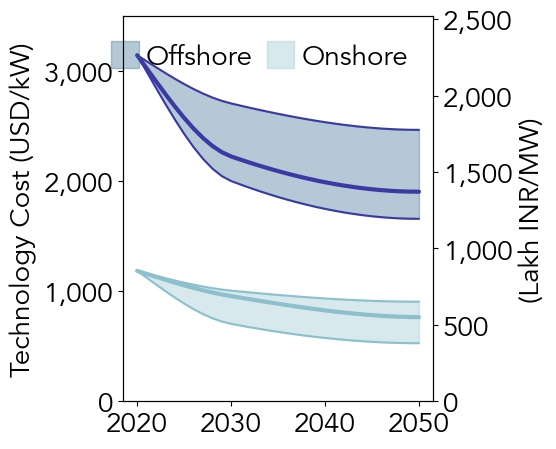

In [17]:
def _plot_wind_cost(ax, df_, 
                    ylabel  = r'Technology Cost (USD/kW)',
                    yplabel = r'(Lakh INR/MW)', 
                    xlabel  = True):

    idx_on_low_  = (df_['scenario'] == 'WDlow') & (df_['technology'] == 'Wind')
    idx_on_mid_  = (df_['scenario'] == 'WDmid') & (df_['technology'] == 'Wind')
    idx_on_high_ = (df_['scenario'] == 'WDhigh') & (df_['technology'] == 'Wind')

    idx_off_low_  = (df_['scenario'] == 'WDlow') & (df_['technology'] == 'Offshore')
    idx_off_mid_  = (df_['scenario'] == 'WDmid') & (df_['technology'] == 'Offshore')
    idx_off_high_ = (df_['scenario'] == 'WDhigh') & (df_['technology'] == 'Offshore')


    ax.plot(df_.loc[idx_off_low_, 'vintage'], df_.loc[idx_off_low_, 'capital_real_cost_per_kw'],
            color = '#3b3aa5', lw = 1.5, solid_capstyle='round')
    ax.plot(df_.loc[idx_off_mid_, 'vintage'], df_.loc[idx_off_mid_, 'capital_real_cost_per_kw'],
            color = '#3b3aa5', lw = 3, solid_capstyle='round')
    ax.plot(df_.loc[idx_off_high_, 'vintage'], df_.loc[idx_off_high_, 'capital_real_cost_per_kw'],
            color = '#3b3aa5', lw = 1.5, solid_capstyle='round')
    
    ax.fill_between(df_.loc[idx_off_mid_, 'vintage'], 
                    df_.loc[idx_off_low_, 'capital_real_cost_per_kw'],
                    df_.loc[idx_off_high_, 'capital_real_cost_per_kw'], 
                    color = '#2a648a', alpha = 0.35, label = 'Offshore')
    
    ax.plot(df_.loc[idx_on_low_, 'vintage'], df_.loc[idx_on_low_, 'capital_real_cost_per_kw'],
            color = '#8dc0cd', lw = 1.5, solid_capstyle='round')
    ax.plot(df_.loc[idx_on_mid_, 'vintage'], df_.loc[idx_on_mid_, 'capital_real_cost_per_kw'],
            color = '#8dc0cd', lw = 3, solid_capstyle='round')
    ax.plot(df_.loc[idx_on_high_, 'vintage'], df_.loc[idx_on_high_, 'capital_real_cost_per_kw'],
            color = '#8dc0cd', lw = 1.5, solid_capstyle='round')
    
    ax.fill_between(df_.loc[idx_on_mid_, 'vintage'], 
                    df_.loc[idx_on_low_, 'capital_real_cost_per_kw'],
                    df_.loc[idx_on_high_, 'capital_real_cost_per_kw'], 
                    color = '#8dc0cd', alpha = 0.35, label = 'Onshore')
    
    ax.legend(loc     = 'upper right',
              ncol    = 2,
              frameon = False,
              prop    = {'size': 20},
              handletextpad = 0.25,
              columnspacing = 0.5)

    x_ = np.array([2020, 2030, 2040, 2050])
    ax.set_xticks(x_, x_, fontsize = 20)
    
    axp = ax.twinx()

    ax.xaxis.set_tick_params(labelsize = 20)
    ax.yaxis.set_tick_params(labelsize = 20)
    axp.yaxis.set_tick_params(labelsize = 20)
    
    ax.set_ylabel(ylabel, fontsize = 20)
    axp.set_ylabel(yplabel, fontsize = 20)
    
    ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
    axp.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
    
    ax.set_ylim(0, 3500)
    axp.set_ylim(0, 3500*USD_to_INR*1000/1e5)
    
    plt.setp(ax.get_xticklabels(), visible = xlabel)


fig, ax = plt.subplots(1, 1, figsize = (4, 5))

_plot_wind_cost(ax, new_wind_costs_all)

# plt.savefig(path_to_images + '/existing_capacity.png', 
#             bbox_inches = 'tight', 
#             dpi         = 300)

plt.show()

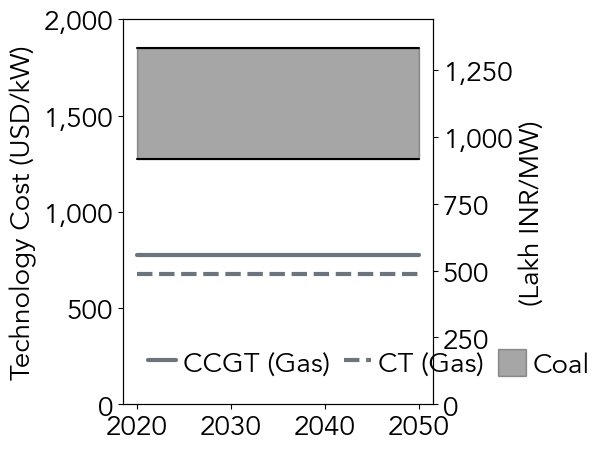

In [18]:
def _plot_convectional_cost(ax, df_,
                            ylabel  = r'Technology Cost (USD/kW)',
                            yplabel = r'(Lakh INR/MW)',
                            xlabel  = True):
    
    idx_coal_low_  = (df_['scenario'] == 'CONVmid') & (df_['technology'] == 'Supercritical_Coal')
    idx_coal_high_ = (df_['scenario'] == 'CONVhigh') & (df_['technology'] == 'Supercritical_Coal')

    idx_ccgt_  = (df_['scenario'] == 'CONVmid') & (df_['technology'] == 'CCGT')
    idx_ct_ = (df_['scenario'] == 'CONVmid') & (df_['technology'] == 'CT')

    ax.plot(df_.loc[idx_ccgt_, 'vintage'], df_.loc[idx_ccgt_, 'capital_real_cost_per_kw'], 
            color = '#6c757d', lw = 3, solid_capstyle='round', label = 'CCGT (Gas)')

    ax.plot(df_.loc[idx_ct_, 'vintage'], df_.loc[idx_ct_, 'capital_real_cost_per_kw'], 
            color = '#6c757d', lw = 3, solid_capstyle='round', ls = '--', label = 'CT (Gas)')
    

    ax.plot(df_.loc[idx_coal_low_, 'vintage'], df_.loc[idx_coal_low_, 'capital_real_cost_per_kw'], 
            color = 'k', lw = 1.5, solid_capstyle='round')
    ax.plot(df_.loc[idx_coal_high_, 'vintage'], df_.loc[idx_coal_high_, 'capital_real_cost_per_kw'], 
            color = 'k', lw = 1.5, solid_capstyle='round')
    
    ax.fill_between(df_.loc[idx_coal_low_, 'vintage'], 
                    df_.loc[idx_coal_low_, 'capital_real_cost_per_kw'],
                    df_.loc[idx_coal_high_, 'capital_real_cost_per_kw'], 
                    color = 'k', alpha = 0.35, label = 'Coal')
    
    
    ax.legend(loc     = 'lower left',
              frameon = False,
              ncol    = 3,
              prop    = {'size': 20}, 
              handletextpad = 0.25,
              columnspacing = 0.5)
    
    x_ = np.array([2020, 2030, 2040, 2050])
    ax.set_xticks(x_, x_, fontsize = 20)
    
    axp = ax.twinx()

    ax.xaxis.set_tick_params(labelsize = 20)
    ax.yaxis.set_tick_params(labelsize = 20)
    axp.yaxis.set_tick_params(labelsize = 20)
    
    ax.set_ylabel(ylabel, fontsize = 20)
    axp.set_ylabel(yplabel, fontsize = 20)
    
    ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
    axp.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))

    ax.set_ylim(0, 2000)
    axp.set_ylim(0, 2000*USD_to_INR*1000/1e5)
    
    plt.setp(ax.get_xticklabels(), visible = xlabel)

    
fig, ax = plt.subplots(1, 1, figsize = (4, 5))

_plot_convectional_cost(ax, new_conventional_costs_all)

# plt.savefig(path_to_images + '/existing_capacity.png', 
#             bbox_inches = 'tight', 
#             dpi         = 300)

plt.show()

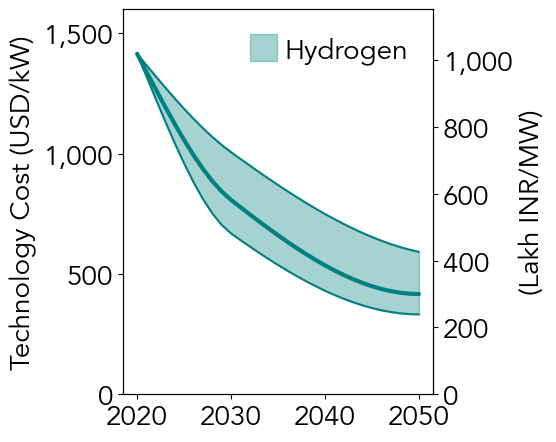

In [19]:
def _plot_hydrogen_power_cost(ax, df_,
                              ylabel  = r'Technology Cost (USD/kW)',
                              yplabel = r'(Lakh INR/MW)',
                              xlabel  = True):
    
    idx_low_  = df_['scenario'] == 'STlow'
    idx_mid_  = df_['scenario'] == 'STmid'
    idx_high_ = df_['scenario'] == 'SThigh'

    ax.plot(df_.loc[idx_low_, 'vintage'], df_.loc[idx_low_, 'capital_real_cost_per_kw'], 
            color = 'teal', lw = 1.5, solid_capstyle='round')
    ax.plot(df_.loc[idx_mid_, 'vintage'], df_.loc[idx_mid_, 'capital_real_cost_per_kw'], 
            color = 'teal', lw = 3, solid_capstyle='round')
    ax.plot(df_.loc[idx_high_, 'vintage'], df_.loc[idx_high_, 'capital_real_cost_per_kw'], 
            color = 'teal', lw = 1.5, solid_capstyle='round')
    
    ax.fill_between(df_.loc[idx_mid_, 'vintage'], 
                    df_.loc[idx_low_, 'capital_real_cost_per_kw'],
                    df_.loc[idx_high_, 'capital_real_cost_per_kw'], 
                    color = 'teal', alpha = 0.35, label = 'Hydrogen')
    
    # ax.xaxis.set_tick_params(labelsize = 14)
    # ax.yaxis.set_tick_params(labelsize = 14)
    # ax.set_ylabel(ylabel, fontsize = 16)
    # ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))

    ax.legend(loc     = 'upper right',
              ncol    = 2,
              frameon = False,
              prop    = {'size': 20},
              handletextpad = 0.25,
              columnspacing = 0.5)
    
    x_ = np.array([2020, 2030, 2040, 2050])
    ax.set_xticks(x_, x_, fontsize = 20)
    
    axp = ax.twinx()

    ax.xaxis.set_tick_params(labelsize = 20)
    ax.yaxis.set_tick_params(labelsize = 20)
    axp.yaxis.set_tick_params(labelsize = 20)
    
    ax.set_ylabel(ylabel, fontsize = 20)
    axp.set_ylabel(yplabel, fontsize = 20)
    
    ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
    axp.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
    
    ax.set_ylim(0, 1600)
    axp.set_ylim(0, 1600*USD_to_INR*1000/1e5)
    
    plt.setp(ax.get_xticklabels(), visible = xlabel)

fig, ax = plt.subplots(1, 1, figsize = (4, 5))

_plot_hydrogen_power_cost(ax, new_hydrogen_cavern_costs_all)

# plt.savefig(path_to_images + '/existing_capacity.png', 
#             bbox_inches = 'tight', 
#             dpi         = 300)

plt.show()

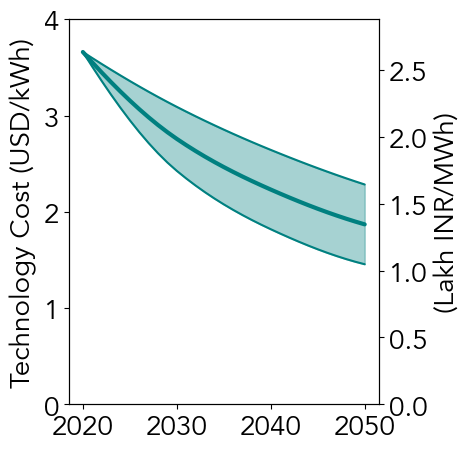

In [20]:
def _plot_hydrogen_energy_cost(ax, df_,
                               ylabel  = r'Technology Cost (USD/kWh)',
                               yplabel = r'(Lakh INR/MWh)',
                               xlabel  = True):
    
    idx_low_  = df_['scenario'] == 'STlow'
    idx_mid_  = df_['scenario'] == 'STmid'
    idx_high_ = df_['scenario'] == 'SThigh'

    ax.plot(df_.loc[idx_low_, 'vintage'], df_.loc[idx_low_, 'capital_real_cost_per_kwh'], 
            color = 'teal', lw = 1.5, solid_capstyle='round')
    ax.plot(df_.loc[idx_mid_, 'vintage'], df_.loc[idx_mid_, 'capital_real_cost_per_kwh'], 
            color = 'teal', lw = 3, solid_capstyle='round')
    ax.plot(df_.loc[idx_high_, 'vintage'], df_.loc[idx_high_, 'capital_real_cost_per_kwh'], 
            color = 'teal', lw = 1.5, solid_capstyle='round')
    
    ax.fill_between(df_.loc[idx_mid_, 'vintage'], 
                    df_.loc[idx_low_, 'capital_real_cost_per_kwh'],
                    df_.loc[idx_high_, 'capital_real_cost_per_kwh'], 
                    color = 'teal', alpha = 0.35, label = 'Tank')
    
#     idx_low_  = df_['scenario'] == 'STlow'
#     idx_mid_  = df_['scenario'] == 'STmid'
#     idx_high_ = df_['scenario'] == 'SThigh'
    
#     # ax.plot(df_.loc[idx_low_, 'vintage'], df_.loc[idx_low_, 'capital_real_cost_per_kwh'], 
#     #         color = 'teal', lw = 1.5)
#     ax.plot(df_.loc[idx_mid_, 'vintage'], df_.loc[idx_mid_, 'capital_real_cost_per_kwh'], 
#             color = 'teal',  lw = 3, label = 'Cavern', solid_capstyle='round')
#     # ax.plot(df_.loc[idx_high_, 'vintage'], df_.loc[idx_high_, 'capital_real_cost_per_kwh'], 
#     #         color = 'teal', lw = 1.5)
    
    # ax.fill_between(df_.loc[idx_mid_, 'vintage'], 
    #                 df_.loc[idx_low_, 'capital_real_cost_per_kwh'],
    #                 df_.loc[idx_high_, 'capital_real_cost_per_kwh'], 
    #                 color = 'teal', alpha = 0.35, label = 'Hydrogen')
    
    ax.xaxis.set_tick_params(labelsize = 20)
    ax.yaxis.set_tick_params(labelsize = 20)
    ax.set_ylabel(ylabel, fontsize = 20)
    #ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))

#     ax.legend(loc     = 'upper right',
#               frameon = False,
#               prop    = {'size': 14})
    
    x_ = np.array([2020, 2030, 2040, 2050])
    ax.set_xticks(x_, x_, fontsize = 20)
    
    axp = ax.twinx()

    ax.xaxis.set_tick_params(labelsize = 20)
    ax.yaxis.set_tick_params(labelsize = 20)
    axp.yaxis.set_tick_params(labelsize = 20)
    
    ax.set_ylabel(ylabel, fontsize = 20)
    axp.set_ylabel(yplabel, fontsize = 20)
    
    #axp.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
    
    ax.set_ylim(0, 4.)
    axp.set_ylim(0, 4.*USD_to_INR*1000/1e5)
    
    plt.setp(ax.get_xticklabels(), visible = xlabel)

fig, ax = plt.subplots(1, 1, figsize = (4, 5))

_plot_hydrogen_energy_cost(ax, new_hydrogen_cavern_costs_all)

# plt.savefig(path_to_images + '/existing_capacity.png', 
#             bbox_inches = 'tight', 
#             dpi         = 300)

plt.show()

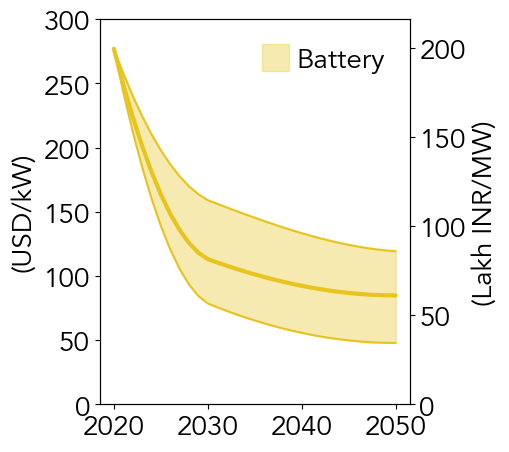

In [21]:
def _plot_battery_power_cost(ax, df_, 
                             ylabel  = r'(USD/kW)', 
                             yplabel = r'(Lakh INR/MW)',
                             xlabel  = True):
    
    idx_low_  = df_['scenario'] == 'STlow'
    idx_mid_  = df_['scenario'] == 'STmid'
    idx_high_ = df_['scenario'] == 'SThigh'

    ax.plot(df_.loc[idx_low_, 'vintage'], df_.loc[idx_low_, 'capital_real_cost_per_kw'], 
            color = '#e7c41f', lw = 1.5, solid_capstyle='round')
    ax.plot(df_.loc[idx_mid_, 'vintage'], df_.loc[idx_mid_, 'capital_real_cost_per_kw'],
            color = '#e7c41f', lw = 3, solid_capstyle='round')
    ax.plot(df_.loc[idx_high_, 'vintage'], df_.loc[idx_high_, 'capital_real_cost_per_kw'],
            color = '#e7c41f', lw = 1.5, solid_capstyle='round')
    
    ax.fill_between(df_.loc[idx_mid_, 'vintage'], 
                    df_.loc[idx_low_, 'capital_real_cost_per_kw'],
                    df_.loc[idx_high_, 'capital_real_cost_per_kw'], 
                    color = '#e7c41f', alpha = 0.35, label = 'Battery')
    
    ax.legend(loc     = 'upper right',
              ncol    = 2,
              frameon = False,
              prop    = {'size': 20},
              handletextpad = 0.25,
              columnspacing = 0.5)
    
    x_ = np.array([2020, 2030, 2040, 2050])
    ax.set_xticks(x_, x_, fontsize = 20)
    
    axp = ax.twinx()

    ax.xaxis.set_tick_params(labelsize = 20)
    ax.yaxis.set_tick_params(labelsize = 20)
    axp.yaxis.set_tick_params(labelsize = 20)
    
    ax.set_ylabel(ylabel, fontsize = 20)
    axp.set_ylabel(yplabel, fontsize = 20)
    
    ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
    axp.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
    
    ax.set_ylim(0, 300)
    axp.set_ylim(0, 300*USD_to_INR*1000/1e5)
    
    plt.setp(ax.get_xticklabels(), visible = xlabel)

fig, ax = plt.subplots(1, 1, figsize = (4, 5))

_plot_battery_power_cost(ax, new_battery_costs_all)

# plt.savefig(path_to_images + '/existing_capacity.png', 
#             bbox_inches = 'tight', 
#             dpi         = 300)

plt.show()

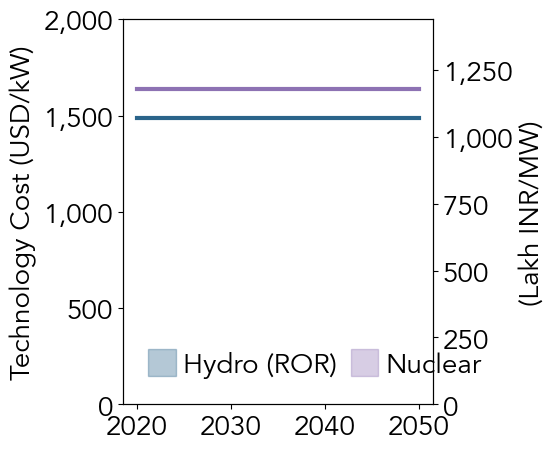

In [22]:
def _plot_nuclear_cost(ax, df_, 
                       hydro_ROR = 1486.11,
                       ylabel    = r'Technology Cost (USD/kW)', 
                       yplabel   = r'(Lakh INR/MW)',
                       xlabel    = True):
    
    idx_nuclear_ = (df_['scenario'] == 'NUCLmid') & (df_['technology'] == 'Nuclear')

    ax.plot(df_.loc[idx_nuclear_, 'vintage'], hydro_ROR*np.ones(df_.loc[idx_nuclear_, 'vintage'].shape[0]), 
            color = '#2a648a', lw = 3)
    
    ax.fill_between(df_.loc[idx_nuclear_, 'vintage'], 
                    hydro_ROR*np.ones(df_.loc[idx_nuclear_, 'vintage'].shape[0]),
                    hydro_ROR*np.ones(df_.loc[idx_nuclear_, 'vintage'].shape[0]), 
                    color = '#2a648a', alpha = 0.35, label = 'Hydro (ROR)')
    
    
    ax.plot(df_.loc[idx_nuclear_, 'vintage'], df_.loc[idx_nuclear_, 'capital_real_cost_per_kw'], 
            color = '#8d72b3', lw = 3)
    
    ax.fill_between(df_.loc[idx_nuclear_, 'vintage'], 
                    df_.loc[idx_nuclear_, 'capital_real_cost_per_kw'],
                    df_.loc[idx_nuclear_, 'capital_real_cost_per_kw'], 
                    color = '#8d72b3', alpha = 0.35, label = 'Nuclear')
    
    ax.legend(loc     = 'lower left',
              ncol    = 2,
              frameon = False,
              prop    = {'size': 20},
              handletextpad = 0.25,
              columnspacing = 0.5)
    
    axp = ax.twinx()
    
    x_ = np.array([2020, 2030, 2040, 2050])
    ax.set_xticks(x_, x_, fontsize = 20)

    ax.xaxis.set_tick_params(labelsize = 20)
    ax.yaxis.set_tick_params(labelsize = 20)
    axp.yaxis.set_tick_params(labelsize = 20)
    
    ax.set_ylabel(ylabel, fontsize = 20)
    axp.set_ylabel(yplabel, fontsize = 20)
    
    ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
    axp.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
    
    ax.set_ylim(0, 2000)
    axp.set_ylim(0, 2000*USD_to_INR*1000/1e5)
    
    plt.setp(ax.get_xticklabels(), visible = xlabel)


fig, ax = plt.subplots(1, 1, figsize = (4, 5))

_plot_nuclear_cost(ax, new_nuclear_costs_all)

# plt.savefig(path_to_images + '/existing_capacity.png', 
#             bbox_inches = 'tight', 
#             dpi         = 300)

plt.show()

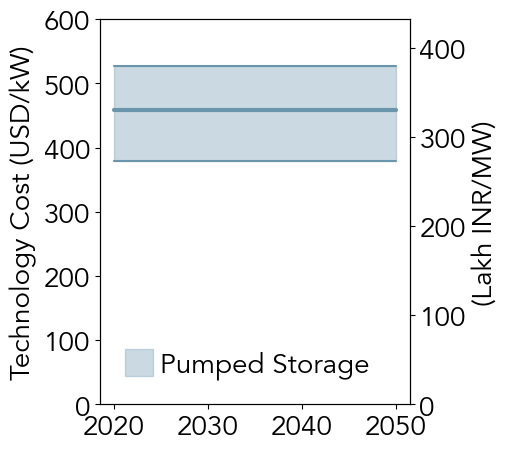

In [23]:
def _plot_phs_power_cost(ax, df_,
                         ylabel  = r'Technology Cost (USD/kW)', 
                         yplabel = r'(Lakh INR/MW)', 
                         xlabel = True):
    
    idx_low_  = df_['scenario'] == 'STlow'
    idx_mid_  = df_['scenario'] == 'STmid'
    idx_high_ = df_['scenario'] == 'SThigh'

    ax.plot(df_.loc[idx_low_, 'vintage'], df_.loc[idx_low_, 'capital_real_cost_per_kw'], 
            color = '#6a96ac', lw = 1.5, solid_capstyle='round')
    ax.plot(df_.loc[idx_mid_, 'vintage'], df_.loc[idx_mid_, 'capital_real_cost_per_kw'],
            color = '#6a96ac', lw = 3, solid_capstyle='round')
    ax.plot(df_.loc[idx_high_, 'vintage'], df_.loc[idx_high_, 'capital_real_cost_per_kw'],
            color = '#6a96ac', lw = 1.5, solid_capstyle='round')
    
    ax.fill_between(df_.loc[idx_mid_, 'vintage'], 
                    df_.loc[idx_low_, 'capital_real_cost_per_kw'],
                    df_.loc[idx_high_, 'capital_real_cost_per_kw'], 
                    color = '#6a96ac', alpha = 0.35, label = 'Pumped Storage')
    
#     idx_nuclear_ = (df_1_['scenario'] == 'NUCLmid') & (df_1_['technology'] == 'Nuclear')

#     ax.plot(df_1_.loc[idx_nuclear_, 'vintage'], df_1_.loc[idx_nuclear_, 'capital_real_cost_per_kw'], 
#             color = '#8d72b3', lw = 3, label = 'Nuclear')
    
    ax.legend(loc     = 'lower left',
              ncol    = 2,
              frameon = False,
              prop    = {'size': 20},
              handletextpad = 0.25,
              columnspacing = 0.5)
    
    x_ = np.array([2020, 2030, 2040, 2050])
    ax.set_xticks(x_, x_, fontsize = 20)
    
    axp = ax.twinx()

    ax.xaxis.set_tick_params(labelsize = 20)
    ax.yaxis.set_tick_params(labelsize = 20)
    axp.yaxis.set_tick_params(labelsize = 20)
    
    ax.set_ylabel(ylabel, fontsize = 20)
    axp.set_ylabel(yplabel, fontsize = 20)
    
    axp.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))

    ax.set_ylim(0, 600)
    axp.set_ylim(0, 600*USD_to_INR*1000/1e5)

    plt.setp(ax.get_xticklabels(), visible = xlabel)

fig, ax = plt.subplots(1, 1, figsize = (4, 5))

_plot_phs_power_cost(ax, new_hydro_costs_all)

# plt.savefig(path_to_images + '/existing_capacity.png', 
#             bbox_inches = 'tight', 
#             dpi         = 300)

plt.show()

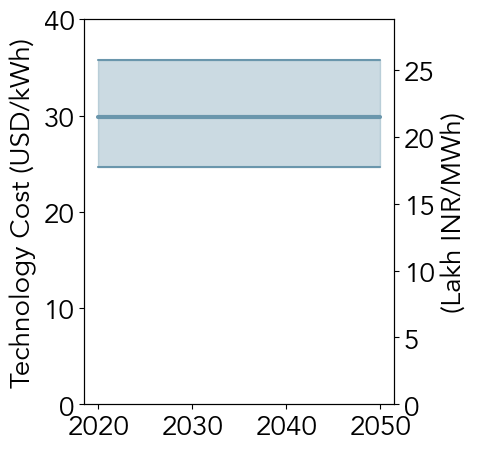

In [24]:
def _plot_phs_energy_cost(ax, df_, 
                          ylabel  = r'Technology Cost (USD/kWh)', 
                          yplabel = r'(Lakh INR/MWh)',
                          xlabel  = True):
    
    idx_low_  = df_['scenario'] == 'STlow'
    idx_mid_  = df_['scenario'] == 'STmid'
    idx_high_ = df_['scenario'] == 'SThigh'

    ax.plot(df_.loc[idx_low_, 'vintage'], df_.loc[idx_low_, 'capital_real_cost_per_kwh'], 
            color = '#6a96ac', lw = 1.5, solid_capstyle='round')
    ax.plot(df_.loc[idx_mid_, 'vintage'], df_.loc[idx_mid_, 'capital_real_cost_per_kwh'],
            color = '#6a96ac', lw = 3, solid_capstyle='round')
    ax.plot(df_.loc[idx_high_, 'vintage'], df_.loc[idx_high_, 'capital_real_cost_per_kwh'],
            color = '#6a96ac', lw = 1.5, solid_capstyle='round')
    
    ax.fill_between(df_.loc[idx_mid_, 'vintage'], 
                    df_.loc[idx_low_, 'capital_real_cost_per_kwh'],
                    df_.loc[idx_high_, 'capital_real_cost_per_kwh'], 
                    color = '#6a96ac', alpha = 0.35, label = 'Pumped Hydro')
    
    # ax.legend(loc     = 'upper right',
    #           frameon = False,
    #           prop    = {'size': 14})
    
    x_ = np.array([2020, 2030, 2040, 2050])
    ax.set_xticks(x_, x_, fontsize = 20)
    
    axp = ax.twinx()
    
    ax.xaxis.set_tick_params(labelsize = 20)
    ax.yaxis.set_tick_params(labelsize = 20)
    axp.yaxis.set_tick_params(labelsize = 20)
    
    ax.set_ylabel(ylabel, fontsize = 20)
    axp.set_ylabel(yplabel, fontsize = 20)

    ax.set_ylim(0, 40)
    axp.set_ylim(0, 40*USD_to_INR*1000/1e5)

    #axp.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))

    plt.setp(ax.get_xticklabels(), visible = xlabel)

fig, ax = plt.subplots(1, 1, figsize = (4, 5))

_plot_phs_energy_cost(ax, new_hydro_costs_all)

# plt.savefig(path_to_images + '/existing_capacity.png', 
#             bbox_inches = 'tight', 
#             dpi         = 300)

plt.show()

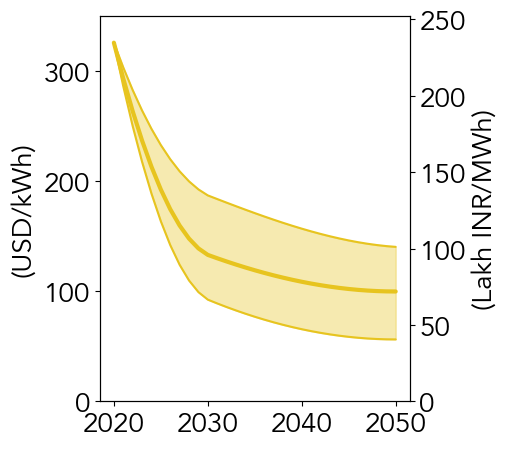

In [25]:
def _plot_battery_energy_cost(ax, df_, 
                              ylabel  = r'(USD/kWh)', 
                              yplabel = r'(Lakh INR/MWh)',
                              xlabel  = True):
    
    idx_low_  = df_['scenario'] == 'STlow'
    idx_mid_  = df_['scenario'] == 'STmid'
    idx_high_ = df_['scenario'] == 'SThigh'

    ax.plot(df_.loc[idx_low_, 'vintage'], df_.loc[idx_low_, 'capital_real_cost_per_kwh'], 
            color = '#e7c41f', lw = 1.5, solid_capstyle='round')
    ax.plot(df_.loc[idx_mid_, 'vintage'], df_.loc[idx_mid_, 'capital_real_cost_per_kwh'],
            color = '#e7c41f', lw = 3, solid_capstyle='round')
    ax.plot(df_.loc[idx_high_, 'vintage'], df_.loc[idx_high_, 'capital_real_cost_per_kwh'],
            color = '#e7c41f', lw = 1.5, solid_capstyle='round')
    
    ax.fill_between(df_.loc[idx_mid_, 'vintage'], 
                    df_.loc[idx_low_, 'capital_real_cost_per_kwh'],
                    df_.loc[idx_high_, 'capital_real_cost_per_kwh'],  
                    color = '#e7c41f', alpha = 0.35, label = 'Battery')
    
#     ax.legend(loc     = 'upper right',
#               frameon = False,
#               prop    = {'size': 14})
    
    ax.xaxis.set_tick_params(labelsize = 20)
    ax.yaxis.set_tick_params(labelsize = 20)
    ax.set_ylabel(ylabel, fontsize = 20)
    
    ax.set_ylim(0, 350)
    
    x_ = np.array([2020, 2030, 2040, 2050])
    ax.set_xticks(x_, x_, fontsize = 20)
    
    axp = ax.twinx()
    
    axp.set_ylim(0, 350*USD_to_INR*1000/1e5)
    axp.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
    axp.yaxis.set_tick_params(labelsize = 20)
    axp.set_ylabel(yplabel, fontsize = 20)

    plt.setp(ax.get_xticklabels(), visible = xlabel)

fig, ax = plt.subplots(1, 1, figsize = (4, 5))

_plot_battery_energy_cost(ax, new_battery_costs_all)

# plt.savefig(path_to_images + '/existing_capacity.png', 
#             bbox_inches = 'tight', 
#             dpi         = 300)

plt.show()

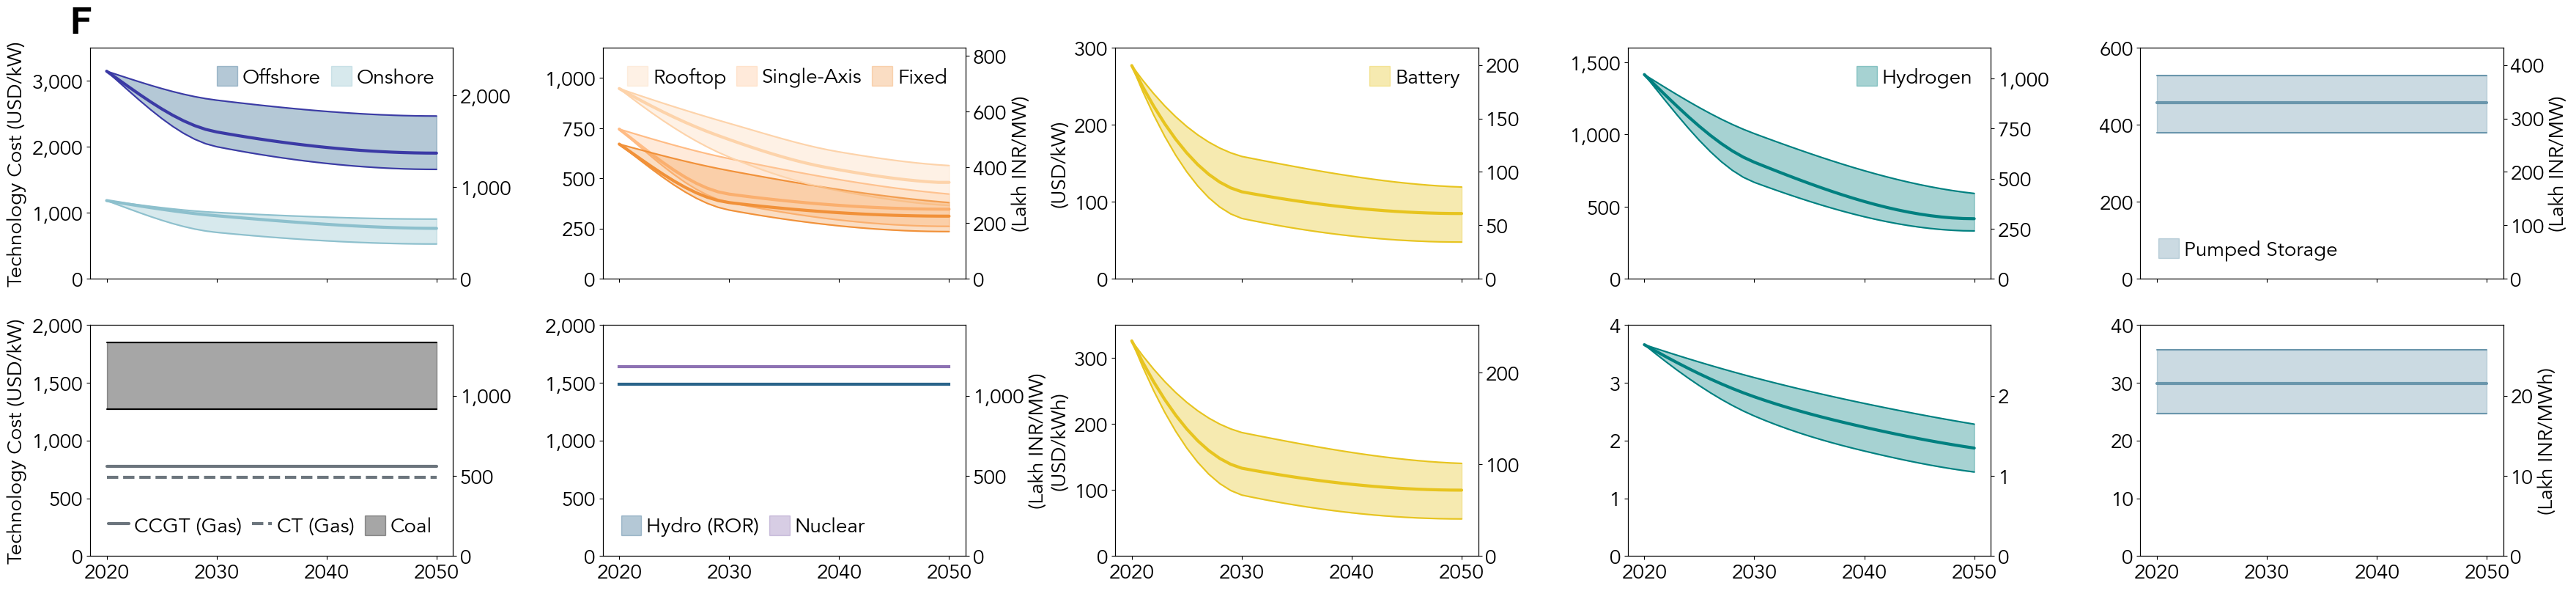

In [26]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C', 'D', 'E'],
                               ['F', 'G', 'H', 'I', 'J']],
                              sharex      = True,
                              figsize     = (42.5, 9.), 
                              gridspec_kw = {'wspace': 0.4125,
                                             'width_ratios': [1, 1, 1, 1, 1]})


_ax['A'].text(0.0, 1.0, 'F', 
        transform = _ax['A'].transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans),
        fontsize  = 36, 
        weight    = "bold",
        va        = 'bottom',
        family    = 'Arial')

new_solar_costs_all.to_csv(path_to_tables + '/input_data-technology_cost_solar_mw.csv', index = False)
new_wind_costs_all.to_csv(path_to_tables + '/input_data-technology_cost_wind_mw.csv', index = False)
new_battery_costs_all.to_csv(path_to_tables + '/input_data-technology_cost_battery_mw.csv', index = False)
new_hydrogen_cavern_costs_all.to_csv(path_to_tables + '/input_data-technology_cost_h2_mw.csv', index = False)
new_hydro_costs_all.to_csv(path_to_tables + '/input_data-technology_cost_psh_mw.csv', index = False)
new_conventional_costs_all.to_csv(path_to_tables + '/input_data-technology_cost_conv_mw.csv', index = False)
new_nuclear_costs_all.to_csv(path_to_tables + '/input_data-technology_cost_nuclear_mw.csv', index = False)
new_battery_costs_all.to_csv(path_to_tables + '/input_data-technology_cost_bettery_mwh.csv', index = False)
new_hydrogen_cavern_costs_all.to_csv(path_to_tables + '/input_data-technology_cost_h2_mwh.csv', index = False)
new_hydro_costs_all.to_csv(path_to_tables + '/input_data-technology_cost_psh_mwh.csv', index = False)

_plot_solar_cost(_ax['B'], new_solar_costs_all, ylabel = '')

_plot_wind_cost(_ax['A'], new_wind_costs_all, yplabel = '')

_plot_battery_power_cost(_ax['C'], new_battery_costs_all, yplabel = '')

_plot_hydrogen_power_cost(_ax['D'], new_hydrogen_cavern_costs_all, ylabel = '', yplabel = '')

_plot_phs_power_cost(_ax['E'], new_hydro_costs_all, ylabel = '')

_plot_convectional_cost(_ax['F'], new_conventional_costs_all, yplabel = '')

_plot_nuclear_cost(_ax['G'], new_nuclear_costs_all, ylabel = '')

_plot_battery_energy_cost(_ax['H'], new_battery_costs_all, yplabel = '')

_plot_hydrogen_energy_cost(_ax['I'], new_hydrogen_cavern_costs_all, ylabel = '', yplabel = '')

_plot_phs_energy_cost(_ax['J'], new_hydro_costs_all, ylabel = '')

plt.savefig(path_to_images + f'/overview-technology_costs.pdf', 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.savefig(path_to_images + f'/overview-technology_costs.png', 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.show()

In [14]:
lw    = 1.5
alpha = 0.75
c_    = ['gray', 'gray', 'gray']
ls_   = ['-', '--', ':', '-.']

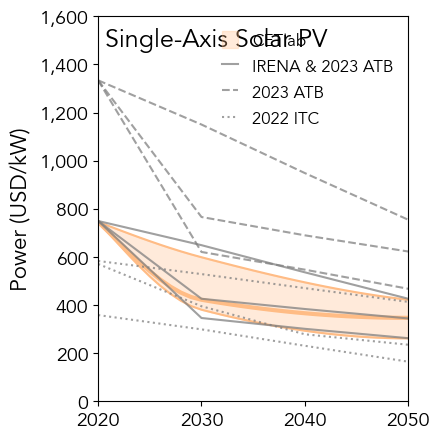

In [15]:
def _plot_singleAxis_costs(_ax, df_1_, df_2_, ls_, c_, lw, alpha, ylabel = 'Power (USD/kW)'):

    idx_low_  = (df_2_['scenario'] == 'PVlow') & (df_2_['technology'] == 'SolarPV_single')
    idx_mid_  = (df_2_['scenario'] == 'PVmid') & (df_2_['technology'] == 'SolarPV_single')
    idx_high_ = (df_2_['scenario'] == 'PVhigh') & (df_2_['technology'] == 'SolarPV_single')
    
    _ax.plot(df_2_.loc[idx_low_, 'vintage'], df_2_.loc[idx_low_, 'capital_real_cost_per_kw'],
            color = '#ffbc85', lw = 1.5, zorder = 1, solid_capstyle='round')
    _ax.plot(df_2_.loc[idx_mid_, 'vintage'], df_2_.loc[idx_mid_, 'capital_real_cost_per_kw'],
            color = '#ffbc85', lw = 3, zorder = 1, solid_capstyle='round')
    _ax.plot(df_2_.loc[idx_high_, 'vintage'], df_2_.loc[idx_high_, 'capital_real_cost_per_kw'],
            color = '#ffbc85', lw = 1.5, zorder = 1, solid_capstyle='round')

    _ax.fill_between(df_2_.loc[idx_mid_, 'vintage'], 
                     df_2_.loc[idx_low_, 'capital_real_cost_per_kw'],
                     df_2_.loc[idx_high_, 'capital_real_cost_per_kw'], 
                     color = '#ffbc85', alpha = .3, zorder = 1, label = 'CETlab')
    
    _ax.plot(df_1_['period'], df_1_['ATB_IRENA_low'], ls = ls_[0], c = c_[0], lw = lw, alpha = alpha, label = 'IRENA & 2023 ATB')
    _ax.plot(df_1_['period'], df_1_['ATB_IRENA_mid'], ls = ls_[0], c = c_[1], lw = lw, alpha = alpha)
    _ax.plot(df_1_['period'], df_1_['ATB_IRENA_high'], ls = ls_[0], c = c_[2], lw = lw, alpha = alpha)
    
    _ax.plot(df_1_['period'], df_1_['ATB_low'], ls = ls_[1], c = c_[0], lw = lw, alpha = alpha, label = '2023 ATB')
    _ax.plot(df_1_['period'], df_1_['ATB_mid'], ls = ls_[1], c = c_[1], lw = lw, alpha = alpha)
    _ax.plot(df_1_['period'], df_1_['ATB_high'], ls = ls_[1], c = c_[2], lw = lw, alpha = alpha)
    
    _ax.plot(df_1_['period'], df_1_['CEA_low'], ls = ls_[2], c = c_[0], lw = lw, alpha = alpha, label = '2022 ITC')
    _ax.plot(df_1_['period'], df_1_['CEA_mid'], ls = ls_[2], c = c_[1], lw = lw, alpha = alpha)
    _ax.plot(df_1_['period'], df_1_['CEA_high'], ls = ls_[2], c = c_[2], lw = lw, alpha = alpha)
    
    _ax.set_ylim(0, 1600)
    _ax.set_xlim(2020, 2050)
    _ax.set_xticks([2020, 2030, 2040, 2050], [2020, 2030, 2040, 2050], fontsize = 20)
    _ax.xaxis.set_tick_params(labelsize = 14)
    _ax.yaxis.set_tick_params(labelsize = 14)
    _ax.set_ylabel(ylabel, fontsize = 16)
    _ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))

    _ax.legend(frameon = False, prop = {'size': 12}, ncol = 1)
    _ax.set_title(' Single-Axis Solar PV', fontsize = 18, y = 0.9, loc = 'left')

df_singleAxis_1_ = pd.read_excel(path_to_data + r'/review-cost_projections.xlsx', 
                                 sheet_name = 'singleAxis_solar')

df_singleAxis_2_ = pd.read_excel(path_to_input + "new_projects_v41.xlsx", 
                                 sheet_name = "adapted_new_solar_costs_2050")

fig, _ax = plt.subplots(figsize = (4, 5))

_plot_singleAxis_costs(_ax, df_singleAxis_1_, df_singleAxis_2_, ls_, c_, lw, alpha)

plt.show()

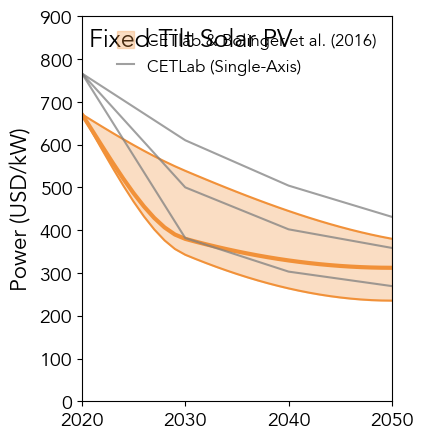

In [16]:
def _plot_fixedTilt_costs(_ax, df_1_, df_2_, ls_, c_, lw, alpha, ylabel = 'Power (USD/kW)'):
    
    idx_low_  = (df_2_['scenario'] == 'PVlow') & (df_2_['technology'] == 'SolarPV_tilt')
    idx_mid_  = (df_2_['scenario'] == 'PVmid') & (df_2_['technology'] == 'SolarPV_tilt')
    idx_high_ = (df_2_['scenario'] == 'PVhigh') & (df_2_['technology'] == 'SolarPV_tilt')

    _ax.plot(df_2_.loc[idx_low_, 'vintage'], df_2_.loc[idx_low_, 'capital_real_cost_per_kw'],
             color = '#f19139', lw = 1.5, solid_capstyle='round', zorder = 1)
    _ax.plot(df_2_.loc[idx_mid_, 'vintage'], df_2_.loc[idx_mid_, 'capital_real_cost_per_kw'],
             color = '#f19139', lw = 3, solid_capstyle='round', zorder = 1)
    _ax.plot(df_2_.loc[idx_high_, 'vintage'], df_2_.loc[idx_high_, 'capital_real_cost_per_kw'],
             color = '#f19139', lw = 1.5, solid_capstyle='round', zorder = 1)

    _ax.fill_between(df_2_.loc[idx_mid_, 'vintage'], 
                     df_2_.loc[idx_low_, 'capital_real_cost_per_kw'],
                     df_2_.loc[idx_high_, 'capital_real_cost_per_kw'], 
                     color = '#f19139', alpha = .3, zorder = 0, label = 'CETlab & Bolinger et al. (2016)')
    
    _ax.plot(df_1_['period'], df_1_['singleAxis_CETLab_low'], ls = ls_[0], c = c_[0], lw = lw, alpha = alpha, zorder = 2, label = 'CETLab (Single-Axis)')
    _ax.plot(df_1_['period'], df_1_['singleAxis_CETLab_mid'], ls = ls_[0], c = c_[1], lw = lw, alpha = alpha, zorder = 2)
    _ax.plot(df_1_['period'], df_1_['singleAxis_CETLab_high'], ls = ls_[0], c = c_[2], lw = lw, alpha = alpha, zorder = 2)
    
    _ax.set_ylim(0, 900)
    _ax.set_xlim(2020, 2050)
    _ax.set_xticks([2020, 2030, 2040, 2050], [2020, 2030, 2040, 2050], fontsize = 20)
    _ax.xaxis.set_tick_params(labelsize = 14)
    _ax.yaxis.set_tick_params(labelsize = 14)
    _ax.set_ylabel(ylabel, fontsize = 16)
    _ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
    
    _ax.legend(frameon = False, prop = {'size': 12}, ncol = 1)
    _ax.set_title(' Fixed-Tilt Solar PV', fontsize = 18, y = 0.9, loc = 'left')

df_fixedTilt_1_ = pd.read_excel(path_to_data + r'/review-cost_projections.xlsx', 
                                sheet_name = 'fixedTilt_solar')

df_fixedTilt_2_ = pd.read_excel(path_to_input + "new_projects_v41.xlsx", 
                                sheet_name = "adapted_new_solar_costs_2050")

fig, _ax = plt.subplots(figsize = (4, 5))

_plot_fixedTilt_costs(_ax, df_fixedTilt_1_, df_fixedTilt_2_, ls_, c_, lw, alpha)

plt.show()

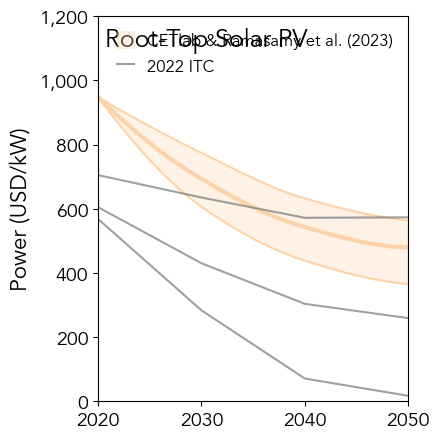

In [17]:
def _plot_roofTop_costs(_ax, df_1_, df_2_, ls_, c_, lw, alpha, ylabel = 'Power (USD/kW)'):

    idx_low_  = (df_2_['scenario'] == 'PVlow') & (df_2_['technology'] == 'SolarPV_roof')
    idx_mid_  = (df_2_['scenario'] == 'PVmid') & (df_2_['technology'] == 'SolarPV_roof')
    idx_high_ = (df_2_['scenario'] == 'PVhigh') & (df_2_['technology'] == 'SolarPV_roof')
    
    _ax.plot(df_2_.loc[idx_low_, 'vintage'], df_2_.loc[idx_low_, 'capital_real_cost_per_kw'],
             color = '#fdd3aa', lw = 1.5, zorder = 2, solid_capstyle='round')
    _ax.plot(df_2_.loc[idx_mid_, 'vintage'], df_2_.loc[idx_mid_, 'capital_real_cost_per_kw'],
             color = '#fdd3aa', lw = 3, zorder = 2, solid_capstyle='round')
    _ax.plot(df_2_.loc[idx_high_, 'vintage'], df_2_.loc[idx_high_, 'capital_real_cost_per_kw'],
             color = '#fdd3aa', lw = 1.5, zorder = 2, solid_capstyle='round')
    
    _ax.fill_between(df_2_.loc[idx_mid_, 'vintage'], 
                     df_2_.loc[idx_low_, 'capital_real_cost_per_kw'],
                     df_2_.loc[idx_high_, 'capital_real_cost_per_kw'], 
                     color = '#fdd3aa', alpha = .3, zorder = 1, label = 'CETlab & Ramasamy et al. (2023)')
    
    _ax.plot(df_1_['period'], df_1_['CEA_low'], ls = ls_[0], c = c_[0], lw = lw, alpha = alpha, label = '2022 ITC')
    _ax.plot(df_1_['period'], df_1_['CEA_mid'], ls = ls_[0], c = c_[1], lw = lw, alpha = alpha)
    _ax.plot(df_1_['period'], df_1_['CEA_high'], ls = ls_[0], c = c_[2], lw = lw, alpha = alpha)
    
    _ax.xaxis.set_tick_params(labelsize = 20)
    _ax.yaxis.set_tick_params(labelsize = 20)
    _ax.set_ylabel(ylabel, fontsize = 20)
    _ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
    
    _ax.set_ylim(0, 1200)
    _ax.set_xlim(2020, 2050)
    _ax.set_xticks([2020, 2030, 2040, 2050], [2020, 2030, 2040, 2050], fontsize = 20)
    _ax.xaxis.set_tick_params(labelsize = 14)
    _ax.yaxis.set_tick_params(labelsize = 14)
    _ax.set_ylabel(ylabel, fontsize = 16)
    _ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
    
    _ax.legend(frameon = False, prop = {'size': 12}, ncol = 1)
    _ax.set_title(' Root-Top Solar PV', fontsize = 18, y = 0.9, loc = 'left')

df_roofTop_1_ = pd.read_excel(path_to_data + r'/review-cost_projections.xlsx', 
                              sheet_name = 'roofTop_solar')

df_roofTop_2_ = pd.read_excel(path_to_input + "new_projects_v41.xlsx", 
                              sheet_name = "adapted_new_solar_costs_2050")

fig, _ax = plt.subplots(figsize = (4, 5))

_plot_roofTop_costs(_ax, df_roofTop_1_, df_roofTop_2_, ls_, c_, lw, alpha)

plt.show()

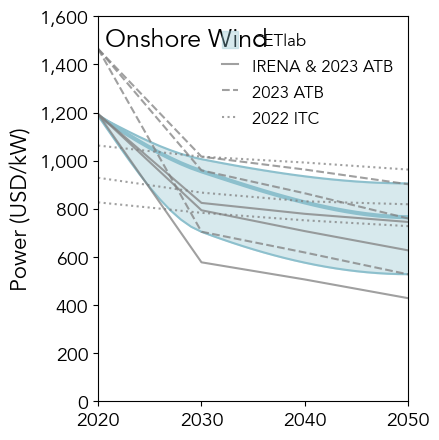

In [18]:
def _plot_onshore_costs(_ax, df_1_, df_2_, ls_, c_, lw, alpha, ylabel = 'Power (USD/kW)'):
    
    idx_low_  = (df_2_['scenario'] == 'WDlow') & (df_2_['technology'] == 'Wind')
    idx_mid_  = (df_2_['scenario'] == 'WDmid') & (df_2_['technology'] == 'Wind')
    idx_high_ = (df_2_['scenario'] == 'WDhigh') & (df_2_['technology'] == 'Wind')
    
    _ax.plot(df_2_.loc[idx_low_, 'vintage'], df_2_.loc[idx_low_, 'capital_real_cost_per_kw'],
            color = '#8dc0cd', lw = 1.5, solid_capstyle='round')
    _ax.plot(df_2_.loc[idx_mid_, 'vintage'], df_2_.loc[idx_mid_, 'capital_real_cost_per_kw'],
            color = '#8dc0cd', lw = 3, solid_capstyle='round')
    _ax.plot(df_2_.loc[idx_high_, 'vintage'], df_2_.loc[idx_high_, 'capital_real_cost_per_kw'],
            color = '#8dc0cd', lw = 1.5, solid_capstyle='round')
    
    _ax.fill_between(df_2_.loc[idx_mid_, 'vintage'], 
                     df_2_.loc[idx_low_, 'capital_real_cost_per_kw'],
                     df_2_.loc[idx_high_, 'capital_real_cost_per_kw'], 
                     color = '#8dc0cd', alpha = 0.35, label = 'CETlab')
    
    _ax.plot(df_1_['period'], df_1_['ATB_IRENA_low'], ls = ls_[0], c = c_[0], lw = lw, alpha = alpha, label = 'IRENA & 2023 ATB')
    _ax.plot(df_1_['period'], df_1_['ATB_IRENA_mid'], ls = ls_[0], c = c_[1], lw = lw, alpha = alpha)
    _ax.plot(df_1_['period'], df_1_['ATB_IRENA_high'], ls = ls_[0], c = c_[2], lw = lw, alpha = alpha)
    
    _ax.plot(df_1_['period'], df_1_['ATB_low'], ls = ls_[1], c = c_[0], lw = lw, alpha = alpha, label = '2023 ATB')
    _ax.plot(df_1_['period'], df_1_['ATB_mid'], ls = ls_[1], c = c_[1], lw = lw, alpha = alpha)
    _ax.plot(df_1_['period'], df_1_['ATB_high'], ls = ls_[1], c = c_[2], lw = lw, alpha = alpha)
    
    _ax.plot(df_1_['period'], df_1_['CEA_low'], ls = ls_[2], c = c_[0], lw = lw, alpha = alpha, label = '2022 ITC')
    _ax.plot(df_1_['period'], df_1_['CEA_mid'], ls = ls_[2], c = c_[1], lw = lw, alpha = alpha)
    _ax.plot(df_1_['period'], df_1_['CEA_high'], ls = ls_[2], c = c_[2], lw = lw, alpha = alpha)
    
    _ax.set_ylim(0, 1600)
    _ax.set_xlim(2020, 2050)
    _ax.set_xticks([2020, 2030, 2040, 2050], [2020, 2030, 2040, 2050], fontsize = 20)
    _ax.xaxis.set_tick_params(labelsize = 14)
    _ax.yaxis.set_tick_params(labelsize = 14)
    _ax.set_ylabel(ylabel, fontsize = 16)
    _ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
    
    _ax.legend(frameon = False, prop = {'size': 12}, ncol = 1)
    _ax.set_title(' Onshore Wind', fontsize = 18, y = 0.9, loc = 'left')

df_onshore_1_ = pd.read_excel(path_to_data + r'/review-cost_projections.xlsx', 
                              sheet_name = 'onshore_wind')

df_onshore_2_ = pd.read_excel(path_to_input + "new_projects_v41.xlsx", 
                              sheet_name = "adapted_new_wind_costs_2050")

fig, _ax = plt.subplots(figsize = (4, 5))

_plot_onshore_costs(_ax, df_onshore_1_, df_onshore_2_, ls_, c_, lw, alpha)

plt.show()

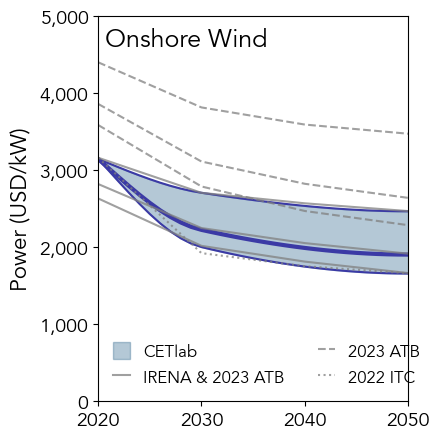

In [19]:
def _plot_offshore_costs(_ax, df_1_, df_2_, ls_, c_, lw, alpha, ylabel = 'Power (USD/kW)'):
    
    idx_low_  = (df_2_['scenario'] == 'WDlow') & (df_2_['technology'] == 'Offshore')
    idx_mid_  = (df_2_['scenario'] == 'WDmid') & (df_2_['technology'] == 'Offshore')
    idx_high_ = (df_2_['scenario'] == 'WDhigh') & (df_2_['technology'] == 'Offshore')

    _ax.plot(df_2_.loc[idx_low_, 'vintage'], df_2_.loc[idx_low_, 'capital_real_cost_per_kw'],
             color = '#3b3aa5', lw = 1.5, solid_capstyle='round')
    _ax.plot(df_2_.loc[idx_mid_, 'vintage'], df_2_.loc[idx_mid_, 'capital_real_cost_per_kw'],
             color = '#3b3aa5', lw = 3, solid_capstyle='round')
    _ax.plot(df_2_.loc[idx_high_, 'vintage'], df_2_.loc[idx_high_, 'capital_real_cost_per_kw'],
             color = '#3b3aa5', lw = 1.5, solid_capstyle='round')
    
    _ax.fill_between(df_2_.loc[idx_mid_, 'vintage'], 
                     df_2_.loc[idx_low_, 'capital_real_cost_per_kw'],
                     df_2_.loc[idx_high_, 'capital_real_cost_per_kw'], 
                     color = '#2a648a', alpha = 0.35, label = 'CETlab')

    _ax.plot(df_1_['period'], df_1_['ATB_IRENA_low'], ls = ls_[0], c = c_[0], lw = lw, alpha = alpha, label = 'IRENA & 2023 ATB')
    _ax.plot(df_1_['period'], df_1_['ATB_IRENA_mid'], ls = ls_[0], c = c_[1], lw = lw, alpha = alpha)
    _ax.plot(df_1_['period'], df_1_['ATB_IRENA_high'], ls = ls_[0], c = c_[2], lw = lw, alpha = alpha)
    
    _ax.plot(df_1_['period'], df_1_['ATB_low'], ls = ls_[1], c = c_[0], lw = lw, alpha = alpha, label = '2023 ATB')
    _ax.plot(df_1_['period'], df_1_['ATB_mid'], ls = ls_[1], c = c_[1], lw = lw, alpha = alpha)
    _ax.plot(df_1_['period'], df_1_['ATB_high'], ls = ls_[1], c = c_[2], lw = lw, alpha = alpha)
    
    _ax.plot(df_1_['period'], df_1_['CEA_mid'], ls = ls_[2], c = c_[1], lw = lw, alpha = alpha, label = '2022 ITC')
    
    _ax.set_ylim(0, 5000)
    _ax.set_xlim(2020, 2050)
    _ax.set_xticks([2020, 2030, 2040, 2050], [2020, 2030, 2040, 2050], fontsize = 20)
    _ax.xaxis.set_tick_params(labelsize = 14)
    _ax.yaxis.set_tick_params(labelsize = 14)
    _ax.set_ylabel(ylabel, fontsize = 16)
    _ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
    
    _ax.legend(frameon = False, prop = {'size': 12}, ncol = 2)
    _ax.set_title(' Onshore Wind', fontsize = 18, y = 0.9, loc = 'left')

df_offshore_1_ = pd.read_excel(path_to_data + r'/review-cost_projections.xlsx', 
                               sheet_name = 'offshore_wind')

df_offshore_2_ = pd.read_excel(path_to_input + "new_projects_v41.xlsx", 
                               sheet_name = "adapted_new_wind_costs_2050")

fig, _ax = plt.subplots(figsize = (4, 5))

_plot_offshore_costs(_ax, df_offshore_1_, df_offshore_2_, ls_, c_, lw, alpha)

plt.show()

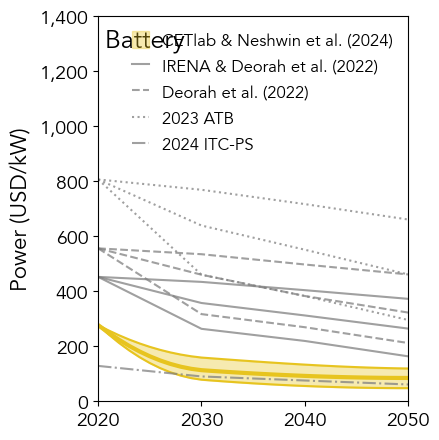

In [20]:
def _plot_bess_mw_costs(_ax, df_1_, df_2_, ls_, c_, lw, alpha, ylabel = 'Power (USD/kW)'):

    idx_low_  = df_2_['scenario'] == 'STlow'
    idx_mid_  = df_2_['scenario'] == 'STmid'
    idx_high_ = df_2_['scenario'] == 'SThigh'

    _ax.plot(df_2_.loc[idx_low_, 'vintage'], df_2_.loc[idx_low_, 'capital_real_cost_per_kw'], 
            color = '#e7c41f', lw = 1.5, solid_capstyle='round')
    _ax.plot(df_2_.loc[idx_mid_, 'vintage'], df_2_.loc[idx_mid_, 'capital_real_cost_per_kw'],
            color = '#e7c41f', lw = 3, solid_capstyle='round')
    _ax.plot(df_2_.loc[idx_high_, 'vintage'], df_2_.loc[idx_high_, 'capital_real_cost_per_kw'],
            color = '#e7c41f', lw = 1.5, solid_capstyle='round')
    
    _ax.fill_between(df_2_.loc[idx_mid_, 'vintage'], 
                    df_2_.loc[idx_low_, 'capital_real_cost_per_kw'],
                    df_2_.loc[idx_high_, 'capital_real_cost_per_kw'],  
                    color = '#e7c41f', alpha = 0.35, label = 'CETlab & Neshwin et al. (2024)')
    
    _ax.plot(df_1_['period'], df_1_['Deorah_IRENA_low'], ls = ls_[0], c = c_[0], lw = lw, alpha = alpha, label = 'IRENA & Deorah et al. (2022)')
    _ax.plot(df_1_['period'], df_1_['Deorah_IRENA_mid'], ls = ls_[0], c = c_[1], lw = lw, alpha = alpha)
    _ax.plot(df_1_['period'], df_1_['Deorah_IRENA_high'], ls = ls_[0], c = c_[2], lw = lw, alpha = alpha)
    
    _ax.plot(df_1_['period'], df_1_['Deorah_low'], ls = ls_[1], c = c_[0], lw = lw, alpha = alpha, label = 'Deorah et al. (2022)')
    _ax.plot(df_1_['period'], df_1_['Deorah_mid'], ls = ls_[1], c = c_[1], lw = lw, alpha = alpha)
    _ax.plot(df_1_['period'], df_1_['Deorah_high'], ls = ls_[1], c = c_[2], lw = lw, alpha = alpha)
    
    _ax.plot(df_1_['period'], df_1_['ATB_low'], ls = ls_[2], c = c_[0], lw = lw, alpha = alpha, label = '2023 ATB')
    _ax.plot(df_1_['period'], df_1_['ATB_mid'], ls = ls_[2], c = c_[1], lw = lw, alpha = alpha)
    _ax.plot(df_1_['period'], df_1_['ATB_high'], ls = ls_[2], c = c_[2], lw = lw, alpha = alpha)
    
    _ax.plot(df_1_['period'], df_1_['CEA_mid'], ls = ls_[3], c = c_[1], lw = lw, alpha = alpha, label = '2024 ITC-PS')
    
    _ax.set_ylim(0, 1400)
    _ax.set_xlim(2020, 2050)
    _ax.set_xticks([2020, 2030, 2040, 2050], [2020, 2030, 2040, 2050], fontsize = 20)
    _ax.xaxis.set_tick_params(labelsize = 14)
    _ax.yaxis.set_tick_params(labelsize = 14)
    _ax.set_ylabel(ylabel, fontsize = 16)
    _ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
    
    _ax.legend(frameon = False, prop = {'size': 12}, ncol = 1)
    _ax.set_title(' Battery', fontsize = 18, y = 0.9, loc = 'left')

df_bess_mw_1_ = pd.read_excel(path_to_data + r'/review-cost_projections.xlsx', 
                      sheet_name = 'bess_mw')

df_bess_mw_2_ = pd.read_excel(path_to_input + "new_projects_v41.xlsx", 
                      sheet_name = "adapted_new_battery_costs_2050")

fig, _ax = plt.subplots(figsize = (4, 5))

_plot_bess_mw_costs(_ax, df_bess_mw_1_, df_bess_mw_2_, ls_, c_, lw, alpha)

plt.show()

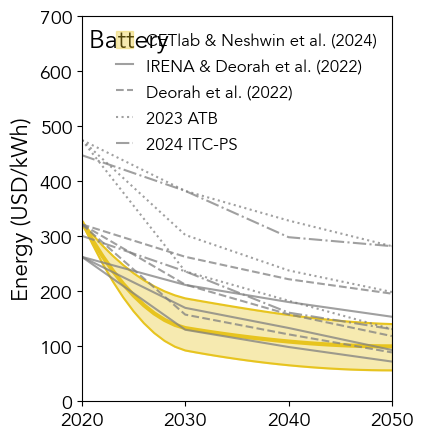

In [21]:
def _plot_bess_mwh_costs(_ax, df_1_, df_2_, ls_, c_, lw, alpha, ylabel = 'Energy (USD/kWh)'):

    idx_low_  = df_2_['scenario'] == 'STlow'
    idx_mid_  = df_2_['scenario'] == 'STmid'
    idx_high_ = df_2_['scenario'] == 'SThigh'

    _ax.plot(df_2_.loc[idx_low_, 'vintage'], df_2_.loc[idx_low_, 'capital_real_cost_per_kwh'], 
            color = '#e7c41f', lw = 1.5, solid_capstyle='round')
    _ax.plot(df_2_.loc[idx_mid_, 'vintage'], df_2_.loc[idx_mid_, 'capital_real_cost_per_kwh'],
            color = '#e7c41f', lw = 3, solid_capstyle='round')
    _ax.plot(df_2_.loc[idx_high_, 'vintage'], df_2_.loc[idx_high_, 'capital_real_cost_per_kwh'],
            color = '#e7c41f', lw = 1.5, solid_capstyle='round')
    
    _ax.fill_between(df_2_.loc[idx_mid_, 'vintage'], 
                    df_2_.loc[idx_low_, 'capital_real_cost_per_kwh'],
                    df_2_.loc[idx_high_, 'capital_real_cost_per_kwh'],  
                    color = '#e7c41f', alpha = 0.35, label = 'CETlab & Neshwin et al. (2024)')
    
    _ax.plot(df_1_['period'], df_1_['Deorah_IRENA_low'], ls = ls_[0], c = c_[0], lw = lw, alpha = alpha, label = 'IRENA & Deorah et al. (2022)')
    _ax.plot(df_1_['period'], df_1_['Deorah_IRENA_mid'], ls = ls_[0], c = c_[1], lw = lw, alpha = alpha)
    _ax.plot(df_1_['period'], df_1_['Deorah_IRENA_high'], ls = ls_[0], c = c_[2], lw = lw, alpha = alpha)
    
    _ax.plot(df_1_['period'], df_1_['Deorah_low'], ls = ls_[1], c = c_[0], lw = lw, alpha = alpha, label = 'Deorah et al. (2022)')
    _ax.plot(df_1_['period'], df_1_['Deorah_mid'], ls = ls_[1], c = c_[1], lw = lw, alpha = alpha)
    _ax.plot(df_1_['period'], df_1_['Deorah_high'], ls = ls_[1], c = c_[2], lw = lw, alpha = alpha)
    
    _ax.plot(df_1_['period'], df_1_['ATB_low'], ls = ls_[2], c = c_[0], lw = lw, alpha = alpha, label = '2023 ATB')
    _ax.plot(df_1_['period'], df_1_['ATB_mid'], ls = ls_[2], c = c_[1], lw = lw, alpha = alpha)
    _ax.plot(df_1_['period'], df_1_['ATB_high'], ls = ls_[2], c = c_[2], lw = lw, alpha = alpha)
    
    _ax.plot(df_1_['period'], df_1_['CEA_low'], ls = ls_[3], c = c_[0], lw = lw, alpha = alpha, label = '2024 ITC-PS')
    _ax.plot(df_1_['period'], df_1_['CEA_high'], ls = ls_[3], c = c_[2], lw = lw, alpha = alpha)
    
    _ax.set_ylim(0, 700)
    _ax.set_xlim(2020, 2050)
    _ax.set_xticks([2020, 2030, 2040, 2050], [2020, 2030, 2040, 2050], fontsize = 20)
    _ax.xaxis.set_tick_params(labelsize = 14)
    _ax.yaxis.set_tick_params(labelsize = 14)
    _ax.set_ylabel(ylabel, fontsize = 16)
    _ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
    
    _ax.legend(frameon = False, prop = {'size': 12}, ncol = 1)
    _ax.set_title(' Battery', fontsize = 18, y = 0.9, loc = 'left')

df_bess_mwh_1_ = pd.read_excel(path_to_data + r'/review-cost_projections.xlsx', 
                               sheet_name = 'bess_mwh')

df_bess_mwh_2_ = pd.read_excel(path_to_input + "new_projects_v41.xlsx", 
                               sheet_name = "adapted_new_battery_costs_2050")

fig, _ax = plt.subplots(figsize = (4, 5))

_plot_bess_mwh_costs(_ax, df_bess_mwh_1_, df_bess_mwh_2_, ls_, c_, lw, alpha)

plt.show()

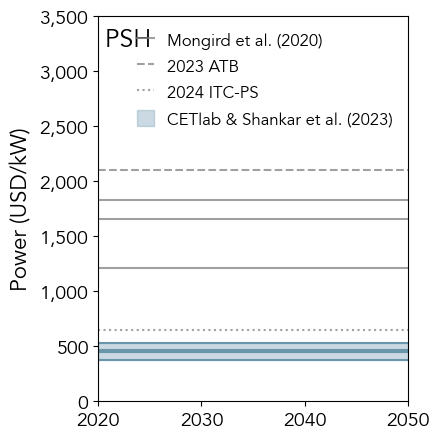

In [22]:
def _plot_psh_mw_costs(_ax, df_1_, df_2_, ls_, c_, lw, alpha, ylabel = 'Power (USD/kW)'):
    
    _ax.plot(df_1_['period'], df_1_['Viswanathan_low'], ls = ls_[0], c = c_[0], lw = lw, alpha = alpha, label = 'Mongird et al. (2020)')
    _ax.plot(df_1_['period'], df_1_['Viswanathan_mid'], ls = ls_[0], c = c_[1], lw = lw, alpha = alpha)
    _ax.plot(df_1_['period'], df_1_['Viswanathan_high'], ls = ls_[0], c = c_[0], lw = lw, alpha = alpha)
    
    _ax.plot(df_1_['period'], df_1_['NREL_mid'], ls = ls_[1], c = c_[1], lw = lw, alpha = alpha, label = '2023 ATB')
    
    _ax.plot(df_1_['period'], df_1_['CEA_mid'], ls = ls_[2], c = c_[1], lw = lw, alpha = alpha, label = '2024 ITC-PS')

    idx_low_  = df_2_['scenario'] == 'STlow'
    idx_mid_  = df_2_['scenario'] == 'STmid'
    idx_high_ = df_2_['scenario'] == 'SThigh'

    _ax.plot(df_2_.loc[idx_low_, 'vintage'], df_2_.loc[idx_low_, 'capital_real_cost_per_kw'], 
            color = '#6a96ac', lw = 1.5, solid_capstyle='round')
    _ax.plot(df_2_.loc[idx_mid_, 'vintage'], df_2_.loc[idx_mid_, 'capital_real_cost_per_kw'],
            color = '#6a96ac', lw = 3, solid_capstyle='round')
    _ax.plot(df_2_.loc[idx_high_, 'vintage'], df_2_.loc[idx_high_, 'capital_real_cost_per_kw'],
            color = '#6a96ac', lw = 1.5, solid_capstyle='round')
    
    _ax.fill_between(df_2_.loc[idx_mid_, 'vintage'], 
                     df_2_.loc[idx_low_, 'capital_real_cost_per_kw'],
                     df_2_.loc[idx_high_, 'capital_real_cost_per_kw'], 
                     color = '#6a96ac', alpha = 0.35, label = 'CETlab & Shankar et al. (2023)')
    
    _ax.set_ylim(0, 3500)
    _ax.set_xlim(2020, 2050)
    _ax.set_xticks([2020, 2030, 2040, 2050], [2020, 2030, 2040, 2050], fontsize = 20)
    _ax.xaxis.set_tick_params(labelsize = 14)
    _ax.yaxis.set_tick_params(labelsize = 14)
    _ax.set_ylabel(ylabel, fontsize = 16)
    _ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
    
    _ax.legend(frameon = False, prop = {'size': 12}, ncol = 1)
    _ax.set_title(' PSH', fontsize = 18, y = 0.9, loc = 'left')

df_psh_mw_1_ = pd.read_excel(path_to_data + r'/review-cost_projections.xlsx', 
                             sheet_name = 'phs_mw')

df_psh_mw_2_ = pd.read_excel(path_to_input + "new_projects_v41.xlsx", 
                             sheet_name = "new_hydro_pumped_costs_2050")

fig, _ax = plt.subplots(figsize = (4, 5))

_plot_psh_mw_costs(_ax, df_psh_mw_1_, df_psh_mw_2_, ls_, c_, lw, alpha)

plt.show()

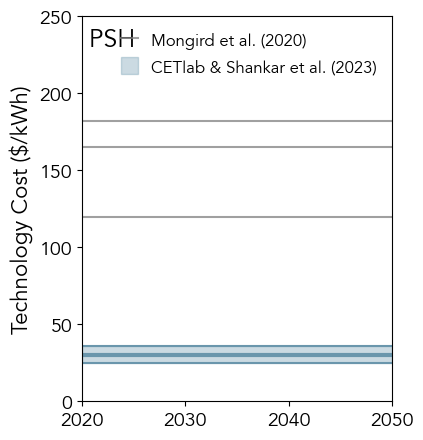

In [33]:
def _plot_psh_mwh_costs(_ax, df_1_, df_2_, ls_, c_, lw, alpha, ylabel = 'Technology Cost ($/kWh)'):
    
    _ax.plot(df_1_['period'], df_1_['Viswanathan_low'], ls = ls_[0], c = c_[0], lw = lw, alpha = alpha, label = 'Mongird et al. (2020)')
    _ax.plot(df_1_['period'], df_1_['Viswanathan_mid'], ls = ls_[0], c = c_[1], lw = lw, alpha = alpha)
    _ax.plot(df_1_['period'], df_1_['Viswanathan_high'], ls = ls_[0], c = c_[2], lw = lw, alpha = alpha)

    idx_low_  = df_2_['scenario'] == 'STlow'
    idx_mid_  = df_2_['scenario'] == 'STmid'
    idx_high_ = df_2_['scenario'] == 'SThigh'

    _ax.plot(df_2_.loc[idx_low_, 'vintage'], df_2_.loc[idx_low_, 'capital_real_cost_per_kwh'], 
            color = '#6a96ac', lw = 1.5, solid_capstyle='round')
    _ax.plot(df_2_.loc[idx_mid_, 'vintage'], df_2_.loc[idx_mid_, 'capital_real_cost_per_kwh'],
            color = '#6a96ac', lw = 3, solid_capstyle='round')
    _ax.plot(df_2_.loc[idx_high_, 'vintage'], df_2_.loc[idx_high_, 'capital_real_cost_per_kwh'],
            color = '#6a96ac', lw = 1.5, solid_capstyle='round')
    
    _ax.fill_between(df_2_.loc[idx_mid_, 'vintage'], 
                     df_2_.loc[idx_low_, 'capital_real_cost_per_kwh'],
                     df_2_.loc[idx_high_, 'capital_real_cost_per_kwh'], 
                     color = '#6a96ac', alpha = 0.35, label = 'CETlab & Shankar et al. (2023)')
    
    _ax.set_ylim(0, 250)
    _ax.set_xlim(2020, 2050)
    _ax.set_xticks([2020, 2030, 2040, 2050], [2020, 2030, 2040, 2050], fontsize = 20)
    _ax.xaxis.set_tick_params(labelsize = 14)
    _ax.yaxis.set_tick_params(labelsize = 14)
    _ax.set_ylabel(ylabel, fontsize = 16)
    _ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
    
    _ax.legend(frameon = False, prop = {'size': 12}, ncol = 1)
    _ax.set_title(' PSH', fontsize = 18, y = 0.9, loc = 'left')

df_psh_mwh_1_ = pd.read_excel(path_to_data + r'/review-cost_projections.xlsx', 
                              sheet_name = 'phs_mwh')

df_psh_mwh_2_ = pd.read_excel(path_to_input + "new_projects_v41.xlsx", 
                              sheet_name = "new_hydro_pumped_costs_2050")

fig, _ax = plt.subplots(figsize = (4, 5))

_plot_psh_mwh_costs(_ax, df_psh_mwh_1_, df_psh_mwh_2_, ls_, c_, lw, alpha)

plt.show()

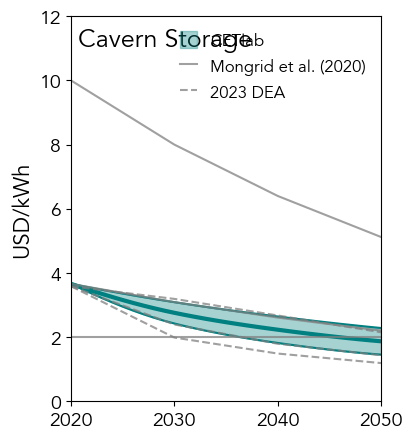

In [34]:
def _plot_h2_storage_costs(_ax, df_1_, df_2_, ls_, c_, lw, alpha, ylabel = 'USD/kWh'):

    idx_low_  = df_2_['scenario'] == 'STlow'
    idx_mid_  = df_2_['scenario'] == 'STmid'
    idx_high_ = df_2_['scenario'] == 'SThigh'

    _ax.plot(df_2_.loc[idx_low_, 'vintage'], df_2_.loc[idx_low_, 'capital_real_cost_per_kwh'], 
            color = 'teal', lw = 1.5, solid_capstyle='round')
    _ax.plot(df_2_.loc[idx_mid_, 'vintage'], df_2_.loc[idx_mid_, 'capital_real_cost_per_kwh'], 
            color = 'teal', lw = 3, solid_capstyle='round')
    _ax.plot(df_2_.loc[idx_high_, 'vintage'], df_2_.loc[idx_high_, 'capital_real_cost_per_kwh'], 
            color = 'teal', lw = 1.5, solid_capstyle='round')
    
    _ax.fill_between(df_2_.loc[idx_mid_, 'vintage'], 
                     df_2_.loc[idx_low_, 'capital_real_cost_per_kwh'],
                     df_2_.loc[idx_high_, 'capital_real_cost_per_kwh'], 
                     color = 'teal', alpha = 0.35, label = 'CETlab')

    _ax.plot(df_1_['period'], df_1_['US_cavern_low'], ls = ls_[0], c = c_[1], lw = lw, alpha = alpha, label = 'Mongrid et al. (2020)')
    _ax.plot(df_1_['period'], df_1_['US_cavern_mid'], ls = ls_[0], c = c_[1], lw = lw, alpha = alpha)
    _ax.plot(df_1_['period'], df_1_['US_cavern_high'], ls = ls_[0], c = c_[1], lw = lw, alpha = alpha)

    _ax.plot(df_1_['period'], df_1_['DEA_cavern_low'], ls = ls_[1], c = c_[1], lw = lw, alpha = alpha, label = '2023 DEA')
    _ax.plot(df_1_['period'], df_1_['DEA_cavern_mid'], ls = ls_[1], c = c_[1], lw = lw, alpha = alpha)
    _ax.plot(df_1_['period'], df_1_['DEA_cavern_high'], ls = ls_[1], c = c_[1], lw = lw, alpha = alpha)

    _ax.set_ylim(0, 12)
    _ax.set_xlim(2020, 2050)
    _ax.set_xticks([2020, 2030, 2040, 2050], [2020, 2030, 2040, 2050], fontsize = 20)
    _ax.xaxis.set_tick_params(labelsize = 14)
    _ax.yaxis.set_tick_params(labelsize = 14)
    _ax.set_ylabel(ylabel, fontsize = 16)
    _ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
    
    _ax.legend(frameon = False, prop = {'size': 12}, ncol = 1)
    _ax.set_title(' Cavern Storage', fontsize = 18, y = 0.9, loc = 'left')

df_h2_storage_1_ = pd.read_excel(path_to_data + r'/review-cost_projections.xlsx', 
                                 sheet_name = 'h2_storage')

df_h2_storage_2_ = pd.read_excel(path_to_input + "new_projects_v41.xlsx", 
                                 sheet_name = "new_hydrogen_cavern_costs_2050")

fig, _ax = plt.subplots(figsize = (4, 5))

_plot_h2_storage_costs(_ax, df_h2_storage_1_, df_h2_storage_2_, ls_, c_, lw, alpha)

plt.show()

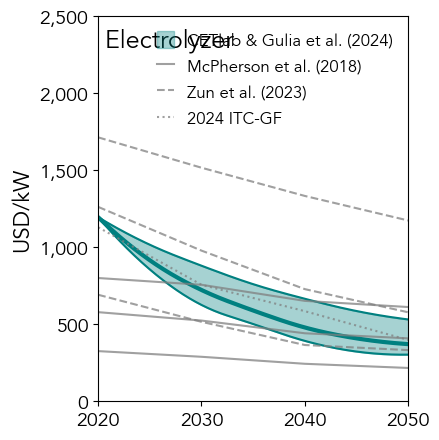

In [35]:
def _plot_electrolyzer_costs(_ax, df_1_, df_2_, ls_, c_, lw, alpha, ylabel = 'USD/kW'):

    x_ = np.linspace(2020, 2050, 300)  

    _ax.plot(x_, inter.make_interp_spline(df_2_['period'], df_2_['low'], k = 2)(x_), 
             color = 'teal', lw = 1.5, solid_capstyle='round', zorder = 0)
    _ax.plot(x_, inter.make_interp_spline(df_2_['period'], df_2_['mid'], k = 2)(x_), 
             color = 'teal', lw = 3, solid_capstyle='round', zorder = 0)
    _ax.plot(x_, inter.make_interp_spline(df_2_['period'], df_2_['high'], k = 2)(x_), 
             color = 'teal', lw = 1.5, solid_capstyle='round', zorder = 0)
    
    _ax.fill_between(x_, 
                     inter.make_interp_spline(df_2_['period'], df_2_['low'], k = 2)(x_),
                     inter.make_interp_spline(df_2_['period'], df_2_['high'], k = 2)(x_), 
                     color = 'teal', alpha = 0.35, label = 'CETlab & Gulia et al. (2024)')
    
    _ax.plot(df_1_['period'], df_1_['McPherson_low'], ls = ls_[0], c = c_[0], lw = lw, alpha = alpha, label = 'McPherson et al. (2018)')
    _ax.plot(df_1_['period'], df_1_['McPherson_mid'], ls = ls_[0], c = c_[1], lw = lw, alpha = alpha)
    _ax.plot(df_1_['period'], df_1_['McPherson_high'], ls = ls_[0], c = c_[2], lw = lw, alpha = alpha)
    
    _ax.plot(df_1_['period'], df_1_['Zun_low'], ls = ls_[1], c = c_[0], lw = lw, alpha = alpha, label = 'Zun et al. (2023)')
    _ax.plot(df_1_['period'], df_1_['Zun_mid'], ls = ls_[1], c = c_[1], lw = lw, alpha = alpha)
    _ax.plot(df_1_['period'], df_1_['Zun_high'], ls = ls_[1], c = c_[2], lw = lw, alpha = alpha)
    
    _ax.plot(df_1_['period'], df_1_['CEA_mid'], ls = ls_[2], c = c_[1], lw = lw, alpha = alpha, label = '2024 ITC-GF')
    
    _ax.set_ylim(0, 2500)
    _ax.set_xlim(2020, 2050)
    _ax.set_xticks([2020, 2030, 2040, 2050], [2020, 2030, 2040, 2050], fontsize = 20)
    _ax.xaxis.set_tick_params(labelsize = 14)
    _ax.yaxis.set_tick_params(labelsize = 14)
    _ax.set_ylabel(ylabel, fontsize = 16)
    _ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
    
    _ax.legend(frameon = False, prop = {'size': 12}, ncol = 1)
    _ax.set_title(' Electrolyzer', fontsize = 18, y = 0.9, loc = 'left')

df_electrolyzer_1_ = pd.read_excel(path_to_data + r'/review-cost_projections.xlsx', 
                                   sheet_name = 'electrolyzer')

df_electrolyzer_2_ = pd.read_excel(path_to_data + r'/review-cost_projections.xlsx', 
                                   sheet_name = 'electrolyzer_projections')

fig, _ax = plt.subplots(figsize = (4, 5))

_plot_electrolyzer_costs(_ax, df_electrolyzer_1_, df_electrolyzer_2_, ls_, c_, lw, alpha)

plt.show()

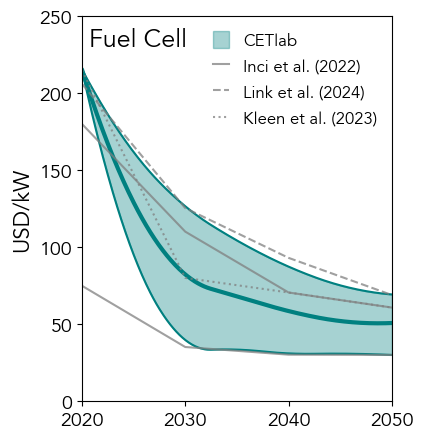

In [36]:
def _plot_h2_fuelCell_costs(_ax, df_1_, df_2_, ls_, c_, lw, alpha, ylabel = 'USD/kW'):

    x_ = np.linspace(2020, 2050, 300)  

    _ax.plot(x_, inter.make_interp_spline(df_2_['period'], df_2_['low'], k = 2)(x_), 
             color = 'teal', lw = 1.5, solid_capstyle='round', zorder = 0)
    _ax.plot(x_, inter.make_interp_spline(df_2_['period'], df_2_['mid'], k = 2)(x_), 
             color = 'teal', lw = 3, solid_capstyle='round', zorder = 0)
    _ax.plot(x_, inter.make_interp_spline(df_2_['period'], df_2_['high'], k = 2)(x_), 
             color = 'teal', lw = 1.5, solid_capstyle='round', zorder = 0)
    
    _ax.fill_between(x_, 
                     inter.make_interp_spline(df_2_['period'], df_2_['low'], k = 2)(x_),
                     inter.make_interp_spline(df_2_['period'], df_2_['high'], k = 2)(x_), 
                     color = 'teal', alpha = 0.35, label = 'CETlab')
    
    _ax.plot(df_1_['period'], df_1_['Inci_low'], ls = ls_[0], c = c_[0], lw = lw, alpha = alpha, label = 'Inci et al. (2022)')
    _ax.plot(df_1_['period'], df_1_['Inci_high'], ls = ls_[0], c = c_[2], lw = lw, alpha = alpha)
    
    _ax.plot(df_1_['period'], df_1_['Link_mid'], ls = ls_[1], c = c_[1], lw = lw, alpha = alpha, label = 'Link et al. (2024)')
    
    _ax.plot(df_1_['period'], df_1_['DEO_mid'], ls = ls_[2], c = c_[1], lw = lw, alpha = alpha, label = 'Kleen et al. (2023)')
    
    _ax.set_ylim(0, 250)
    _ax.set_xlim(2020, 2050)
    _ax.set_xticks([2020, 2030, 2040, 2050], [2020, 2030, 2040, 2050], fontsize = 20)
    _ax.xaxis.set_tick_params(labelsize = 14)
    _ax.yaxis.set_tick_params(labelsize = 14)
    _ax.set_ylabel(ylabel, fontsize = 16)
    _ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))
    
    _ax.legend(frameon = False, prop = {'size': 12}, ncol = 1)
    _ax.set_title(' Fuel Cell', fontsize = 18, y = 0.9, loc = 'left')

df_h2_fuelCell_1_ = pd.read_excel(path_to_data + r'/review-cost_projections.xlsx', 
                                  sheet_name = 'h2_fuelCell')

df_h2_fuelCell_2_ = pd.read_excel(path_to_data + r'/review-cost_projections.xlsx', 
                                  sheet_name = 'h2_fuelCell_projections')

fig, _ax = plt.subplots(figsize = (4, 5))

_plot_h2_fuelCell_costs(_ax, df_h2_fuelCell_1_, df_h2_fuelCell_2_, ls_, c_, lw, alpha)

plt.show()

In [37]:
# def _plot_thermal_cost(_ax, df_1_, df_2_, ls_, c_, lw, alpha, ylabel = 'Power ($/kW)'):
    
#     idx_coal_low_  = (df_1_['scenario'] == 'CONVmid') & (df_1_['technology'] == 'Supercritical_Coal')
#     idx_coal_high_ = (df_1_['scenario'] == 'CONVhigh') & (df_1_['technology'] == 'Supercritical_Coal')

#     idx_ccgt_ = (df_1_['scenario'] == 'CONVmid') & (df_1_['technology'] == 'CCGT')
#     idx_ct_   = (df_1_['scenario'] == 'CONVmid') & (df_1_['technology'] == 'CT')

#     _ax.plot(df_1_.loc[idx_ccgt_, 'vintage'], df_1_.loc[idx_ccgt_, 'capital_real_cost_per_kw'], 
#             color = '#6c757d', lw = 3, solid_capstyle='round', label = 'CCGT (Gas)')

#     _ax.plot(df_1_.loc[idx_ct_, 'vintage'], df_1_.loc[idx_ct_, 'capital_real_cost_per_kw'], 
#             color = '#6c757d', lw = 3, solid_capstyle='round', ls = '--', label = 'CT (Gas)')
    
#     _ax.plot(df_1_.loc[idx_coal_low_, 'vintage'], df_1_.loc[idx_coal_low_, 'capital_real_cost_per_kw'], 
#             color = 'k', lw = 1.5, solid_capstyle='round')
#     _ax.plot(df_1_.loc[idx_coal_high_, 'vintage'], df_1_.loc[idx_coal_high_, 'capital_real_cost_per_kw'], 
#             color = 'k', lw = 1.5, solid_capstyle='round')
    
#     _ax.fill_between(df_1_.loc[idx_coal_low_, 'vintage'], 
#                     df_1_.loc[idx_coal_low_, 'capital_real_cost_per_kw'],
#                     df_1_.loc[idx_coal_high_, 'capital_real_cost_per_kw'], 
#                     color = 'k', alpha = 0.35, label = 'Coal')

#     idx_nuclear_ = (df_2_['scenario'] == 'NUCLmid') & (df_2_['technology'] == 'Nuclear')
    
#     _ax.plot(df_2_.loc[idx_nuclear_, 'vintage'], df_2_.loc[idx_nuclear_, 'capital_real_cost_per_kw'], 
#              color = '#8d72b3', lw = 3, label = 'Nuclear')
    
#     _ax.set_ylim(0, 3000)
#     _ax.set_xlim(2020, 2050)
#     _ax.set_xticks([2020, 2030, 2040, 2050], [2020, 2030, 2040, 2050], fontsize = 20)
#     _ax.xaxis.set_tick_params(labelsize = 12)
#     _ax.yaxis.set_tick_params(labelsize = 12)
#     _ax.set_ylabel(ylabel, fontsize = 14)
#     _ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))

#     _ax.legend(frameon = False, loc = (.45, .625), prop = {'size': 11}, ncol = 2)
#     _ax.set_title('Thermal', fontsize = 16, y = 0.9)

# df_thermal_ = pd.read_excel(path_to_input + "new_projects_v41.xlsx", 
#                             sheet_name = "new_conventional_costs_2050")

# df_nuclear_ = pd.read_excel(path_to_input + "new_projects_v41.xlsx", 
#                             sheet_name = "new_nuclear_costs_2050")

# fig, _ax = plt.subplots(figsize = (4, 5))

# _plot_thermal_cost(_ax, df_thermal_, df_nuclear_, ls_, c_, lw, alpha)

# plt.show()

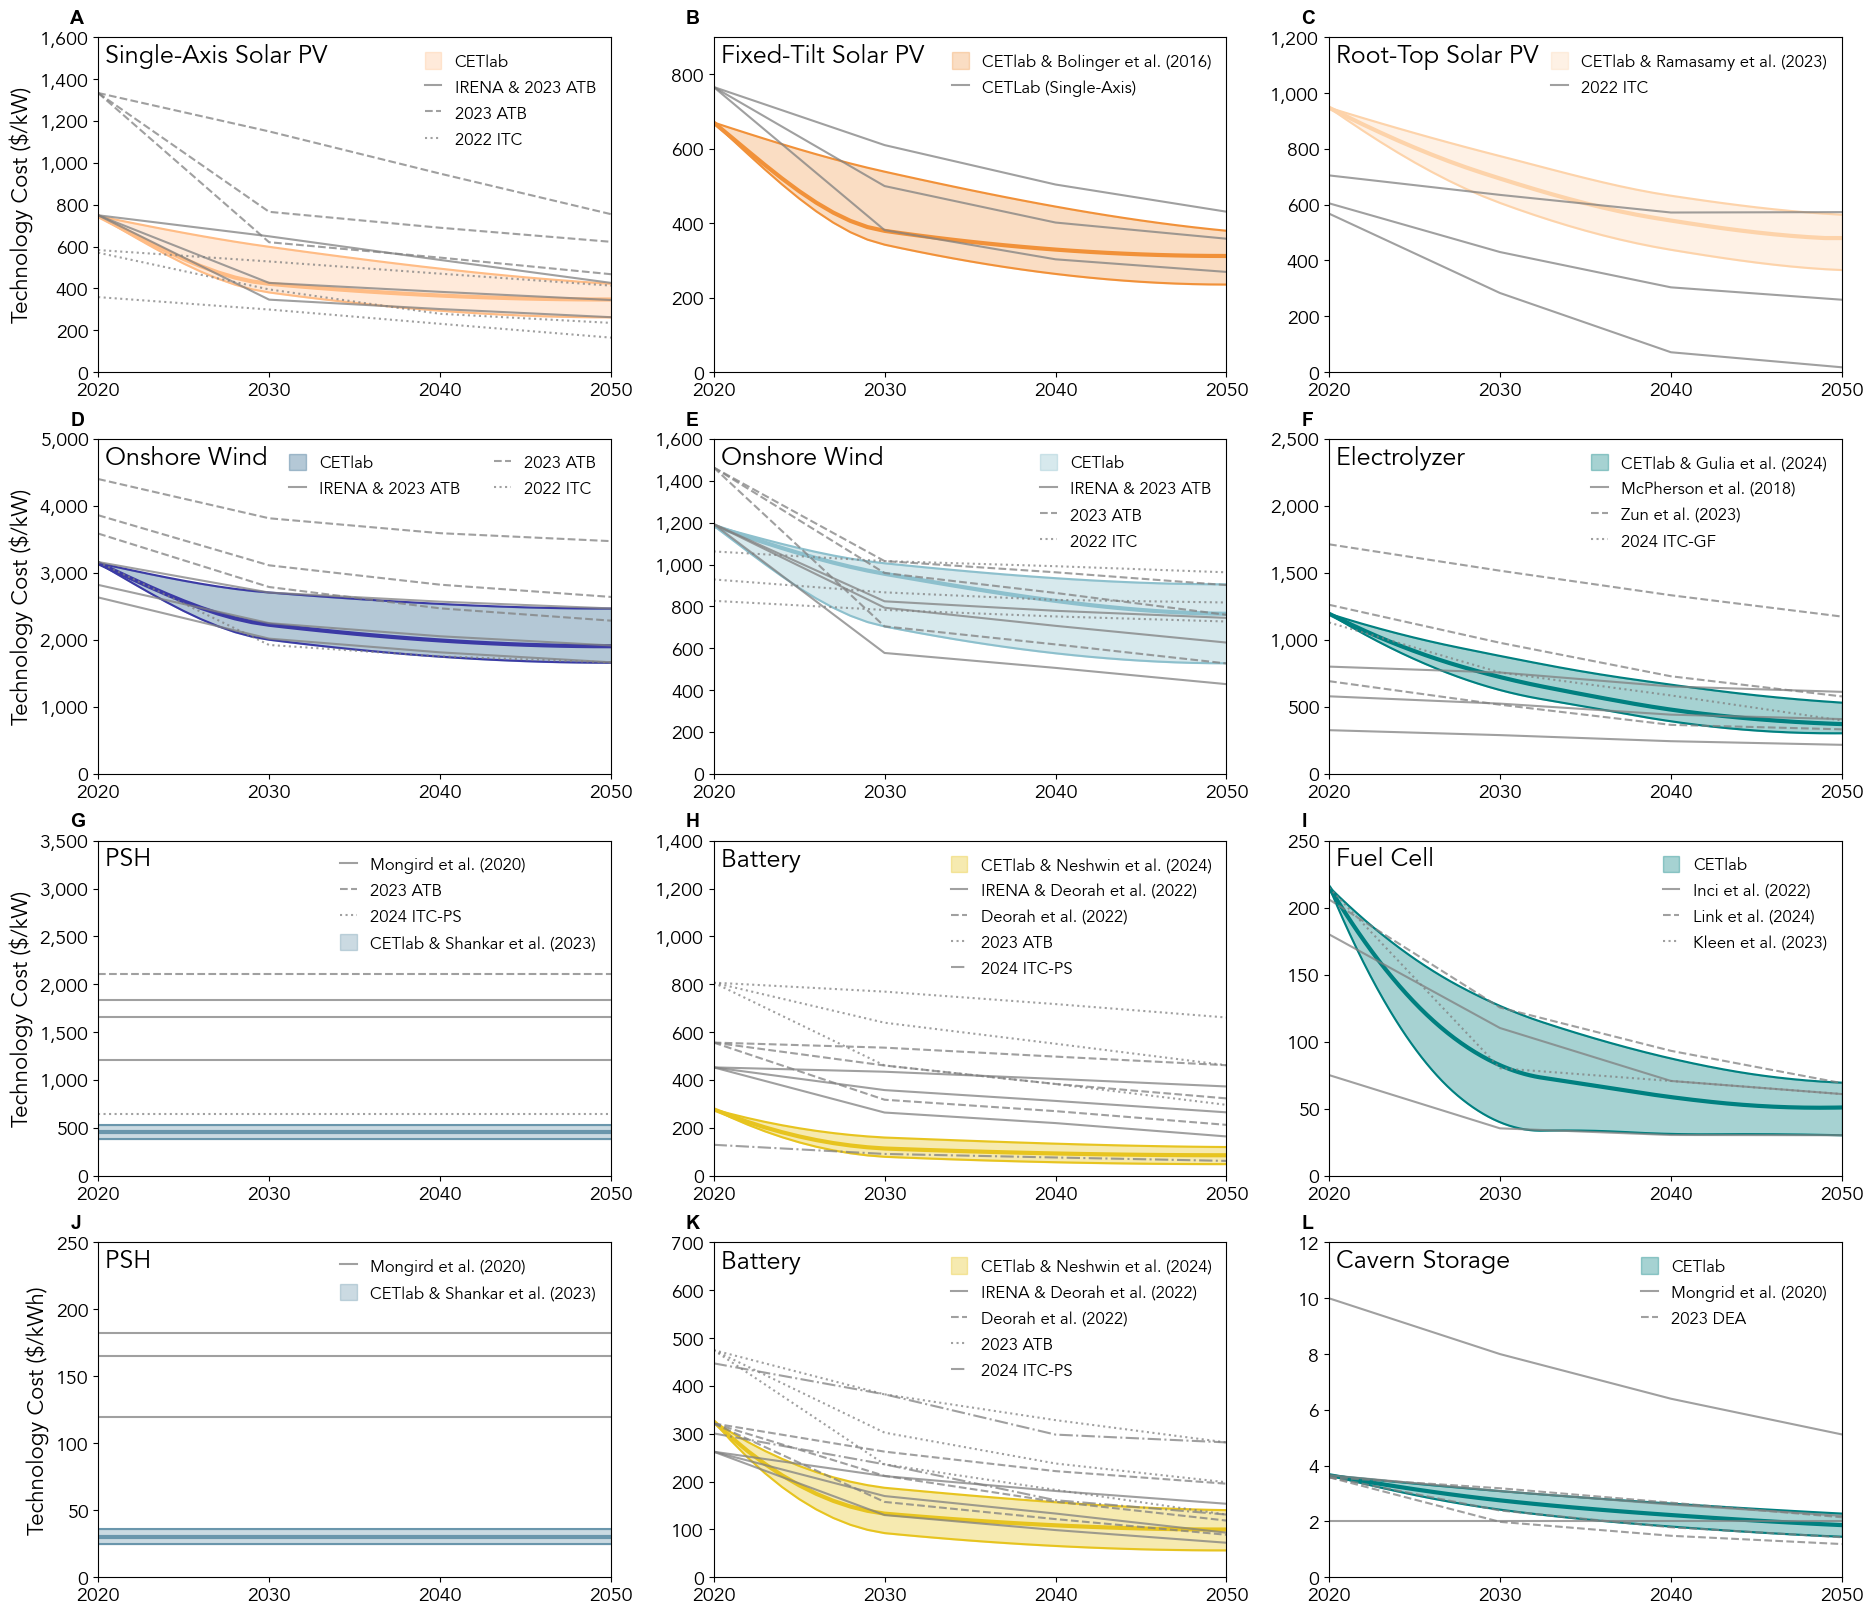

In [38]:
fig, _ax = plt.subplot_mosaic([['A', 'B', 'C'], 
                               ['D', 'E', 'F'],
                               ['G', 'H', 'I'],
                               ['J', 'K', 'L']],
                              figsize     = (22.5, 20), 
                              gridspec_kw = {'width_ratios': [1, 1, 1]})

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, 
            transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
            fontsize  = 14, 
            weight    = "bold",
            va        = 'bottom',
            family    = 'Arial')

_plot_singleAxis_costs(_ax['A'], df_singleAxis_1_, df_singleAxis_2_, ls_, c_, lw, alpha, ylabel = 'Technology Cost ($/kW)')

_plot_fixedTilt_costs(_ax['B'], df_fixedTilt_1_, df_fixedTilt_2_, ls_, c_, lw, alpha, ylabel = '')

_plot_roofTop_costs(_ax['C'], df_roofTop_1_, df_roofTop_2_, ls_, c_, lw, alpha, ylabel = '')

_plot_offshore_costs(_ax['D'], df_offshore_1_, df_offshore_2_, ls_, c_, lw, alpha, ylabel = 'Technology Cost ($/kW)')

_plot_onshore_costs(_ax['E'], df_onshore_1_, df_onshore_2_, ls_, c_, lw, alpha, ylabel = '')

_plot_electrolyzer_costs(_ax['F'], df_electrolyzer_1_, df_electrolyzer_2_, ls_, c_, lw, alpha, ylabel = '')

_plot_psh_mw_costs(_ax['G'], df_psh_mw_1_, df_psh_mw_2_, ls_, c_, lw, alpha, ylabel = 'Technology Cost ($/kW)')

_plot_bess_mw_costs(_ax['H'], df_bess_mw_1_, df_bess_mw_2_, ls_, c_, lw, alpha, ylabel = '')

_plot_h2_fuelCell_costs(_ax['I'], df_h2_fuelCell_1_, df_h2_fuelCell_2_, ls_, c_, lw, alpha, ylabel = '')

_plot_psh_mwh_costs(_ax['J'], df_psh_mwh_1_, df_psh_mwh_2_, ls_, c_, lw, alpha, ylabel = 'Technology Cost ($/kWh)')

_plot_bess_mwh_costs(_ax['K'], df_bess_mwh_1_, df_bess_mwh_2_, ls_, c_, lw, alpha, ylabel = '')

_plot_h2_storage_costs(_ax['L'], df_h2_storage_1_, df_h2_storage_2_, ls_, c_, lw, alpha, ylabel = '')

plt.savefig(path_to_images + '/SI-technology_costs.pdf', 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.savefig(path_to_images + '/SI-technology_costs.png', 
            bbox_inches = 'tight', 
            dpi         = 300)

plt.show()